# Library Imports and Configs

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import f1_score, precision_score, recall_score, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
from sentence_transformers import SentenceTransformer
from scipy.stats import spearmanr, mannwhitneyu, norm, kruskal
from patsy import dmatrix
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import statsmodels.api as sm
import re
import ast


In [3]:
# Matplotlib & Seaborn
%matplotlib inline

mck_palette = [
    "#002F6C",  # McKinsey Blue 
    "#1f77b4",  # Standard blue 
    "#5dade2",  # Light blue accent
    "#000000",  # Black
    "#7f7f7f"   # Gray 
]

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "0.8",
    "axes.linewidth": 0.8,
    "grid.color": "0.9",
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "font.family": "sans-serif"
})

sns.set_context("notebook", font_scale=0.9)
sns.set_style("white")
sns.set_palette(sns.color_palette(mck_palette))

# Pandas
pd.set_option('display.max_columns', 500)

# Random
RANDOM_SEED = 1
np.random.seed(RANDOM_SEED)

# Exploratory Data Analysis (EDA)

In [5]:
df = pd.read_csv("../data/dataset_ifest_2025.csv")

### General EDA

Tampak terdapat 6 fitur pada dataset ini dengan fitur popularity yang bersifat numerikal

In [8]:
df.head(10)

,movie_title,genre_label,language,summary,popularity,release_date
0,Ace Ventura: When Nature Calls,"Crime,Comedy,Adventure",en,"Summoned from an ashram in Tibet, Ace finds hi...",28.877,1995-11-10
1,The Wave,Thriller,no,"Although theorised, no one is really ready whe...",28.675,2015-08-28
2,Spotlight,NaN,en,The true story of how the Boston Globe uncover...,13.601,2015-11-06
3,The Medallion,"Thriller,Fantasy,Action,Comedy",en,A Hong Kong detective suffers a fatal accident...,17.180,2003-08-15
4,Caro diario,NaN,it,Nanni Moretti recalls in his diary three slice...,6.270,1993-10-12
5,Half Nelson,Drama,en,Despite his dedication to the junior-high stud...,10.650,2006-08-11
6,Layer Cake,NaN,en,When a seemingly straight-forward drug deal go...,14.166,2004-09-30
7,Sorcerer,"Adventure,Thriller",en,"Four men from different parts of the globe, al...",18.015,1977-06-24
8,Six Days Seven Nights,"Adventure,Action,Comedy,Romance",en,"When Quinn, a grouchy pilot living the good li...",18.586,1998-06-12
9,The Birdcage,Comedy,en,A gay cabaret owner and his drag queen compani...,11.131,1996-03-08


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12999 entries, 0 to 12998
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_title   12999 non-null  object 
 1   genre_label   10999 non-null  object 
 2   language      12999 non-null  object 
 3   summary       12994 non-null  object 
 4   popularity    12999 non-null  float64
 5   release_date  12999 non-null  object 
dtypes: float64(1), object(5)
memory usage: 609.5+ KB


In [10]:
df.shape

(12999, 6)

In [11]:
df.describe()

,popularity
count,12999.000000
mean,33.225649
std,189.045262
min,0.600000
25%,9.119500
50%,13.577000
75%,25.405000
max,10436.917000


In [12]:
for col in df.columns:
    print(f"{col} nunique: {df[col].nunique()}")

movie_title nunique: 9652
genre_label nunique: 1876
language nunique: 43
summary nunique: 9985
popularity nunique: 8502
release_date nunique: 6111


Hanya terdapat 2 fitur yang memiliki missing values, yaitu genre_label (2000) dan summary (5). Kedua fitur ini memerlukan preprocessing tersendiri

In [14]:
df.isna().sum()

movie_title        0
genre_label     2000
language           0
summary            5
popularity         0
release_date       0
dtype: int64

In [15]:
df.duplicated().sum()

3008

### Feature Specific EDA

#### Movie Title dan Summary

Tampak bahwa movie title dan summary memiliki format konsisten: title terkapitalisasi dan summary menggunakan bahasa inggris dan summary seluruhnya berbahasa inggris dan tidak tampak terdapat kesalahan pada penulisan, bahkan untuk movie dengan bahasa bukan Inggris sekalipun

In [19]:
df[["movie_title", "summary"]].sample(10)

,movie_title,summary
209,The Panic in Needle Park,A stark portrayal of life among a group of her...
9577,I Origins,I Origins follows a molecular biologist studyi...
5670,The Forbidden Kingdom,An American teenager who is obsessed with Hong...
396,Return to Sleepaway Camp,It's summer camp as usual at Camp Manabe where...
7293,Two Women,Widowed shopkeeper Cesira and her 13-year-old ...
5500,Master Z: Ip Man Legacy,"Following his defeat by Master Ip, Cheung Tin ..."
12413,Herbie Fully Loaded,"Maggie Peyton, the new owner of Number 53 - th..."
5732,Nine 1/2 Weeks,"An erotic story about a woman, the assistant o..."
12566,Red Planet,Astronauts search for solutions to save a dyin...
7682,Breakthrough,Tragedy strikes when a woman named Joyce's son...


In [20]:
df[~(df["language"] == "en")][["movie_title", "language", "summary"]].sample(10)

,movie_title,language,summary
10838,Ayla: The Daughter of War,tr,"In 1950, amidst the ravages of the Korean War,..."
1814,Borotalco,it,Sergio Benvenuti is a shy seller of contracts ...
12640,One Piece: Strong World,ja,"20 years after his escape from Impel Down, the..."
4981,Battleship Potemkin,ru,A dramatized account of a great Russian naval ...
777,Addio fottuti musi verdi,it,"Young Cyrus Priello, an ultra-skilled Neapolit..."
2176,Those Happy Days,fr,"Set in 1992, a manager Vincent has to run a ch..."
8465,Spread Your Wings,fr,"Christian, a visionary scientist, studies wild..."
7468,Tutta colpa di Freud,it,Francesco is a psychoanalyst grappling with th...
10513,The Gendarme and the Creatures from Outer Space,fr,The bungling inspector Cruchot (Funès) finds h...
11730,On a Magical Night,fr,"After 20 years of marriage, Maria decides to l..."


#### Genre Label

Berdasarkan format genre_label di bawah tampka bahwa genre dapat berisi lebih dari 1 yang dipisah oleh koma ','

In [23]:
df["genre_label"].sample(5)

10165    TV Movie,Fantasy,Family,Comedy
10472                   Action,Thriller
5920              Crime,Action,Thriller
4225                                NaN
792                Drama,Horror,Mystery
Name: genre_label, dtype: object

#### Language

Dari unique values di bawah, tampak bahwa terdapat beberapa alias yang dapat di-map pada kode yang sama, misal 'zh' dan 'cn' yang merupakan kode bahasa untuk Chinese (dapat di-map).

In [26]:
df["language"].unique()

array(['en', 'no', 'it', 'fr', 'de', 'hi', 'ja', 'ko', 'es', 'zh', 'cn',
       'th', 'ru', 'sv', 'pt', 'hu', 'fi', 'da', 'eu', 'ml', 'ar', 'is',
       'pl', 'et', 'fa', 'sr', 'id', 'uk', 'ab', 'tr', 'cs', 'ro', 'nl',
       'el', 'la', 'te', 'nb', 'sh', 'bn', 'af', 'xx', 'bs', 'he'],
      dtype=object)

Seluruh alias language:
1. 'cn': 'zh' (Chinese)
2. 'sh': 'sr' (sh deprecated; sr Serbian)

Dengan frekuensi yang sangat rendah (1), maka baris ini dapat didrop

In [29]:
df[df["language"] == "xx"]

,movie_title,genre_label,language,summary,popularity,release_date
8513,The Adventures of André and Wally B.,"Family,Animation,Comedy",xx,There's nothing like a restful nap in a pleasa...,11.077,1984-12-17


#### Release Date

Berdasarkan tahun rilis, didapatkan distribusi film sebagai berikut.

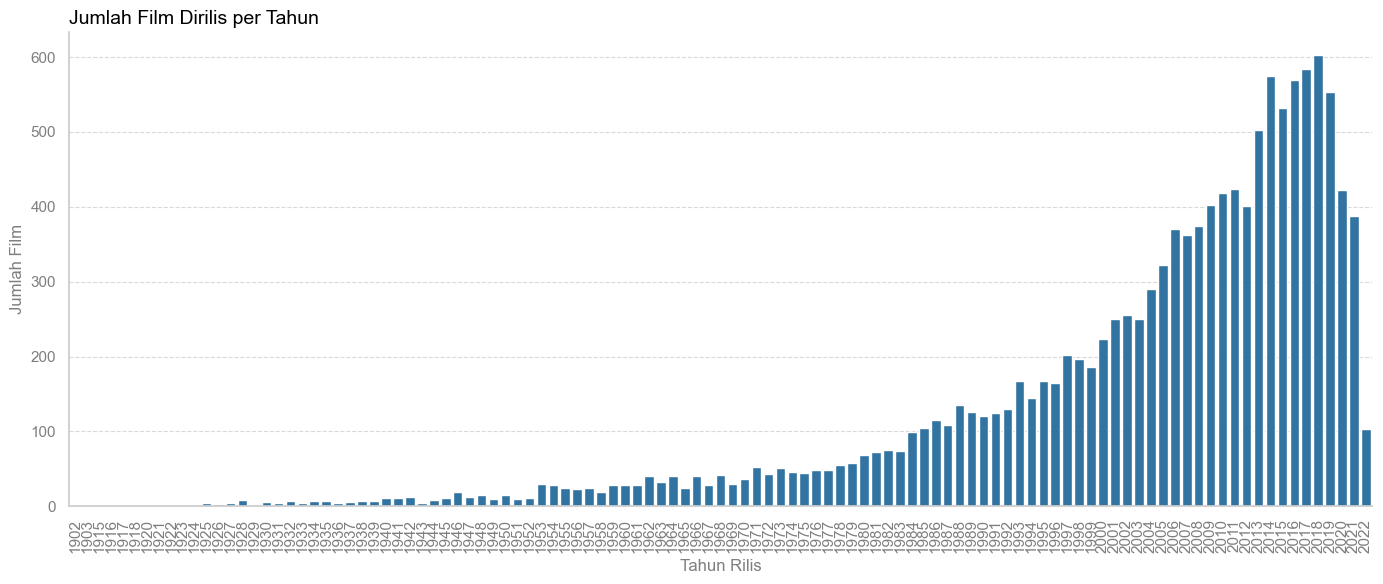

In [32]:
MCK_PALETTE = ["#003366", "#1F77B4", "#6BAED6"]  # dark → light blue

sns.set_theme(style="whitegrid")
sns.set_palette(MCK_PALETTE)

df_time = df.copy()
df_time["release_date"] = pd.to_datetime(df_time["release_date"], errors="coerce")
df_time["release_year"] = df_time["release_date"].dt.year

counts = df_time["release_year"].value_counts().sort_index().reset_index()
counts.columns = ["release_year", "n_films"]

fig, ax = plt.subplots(figsize=(14,6))
sns.barplot(
    data=counts,
    x="release_year",
    y="n_films",
    color=MCK_PALETTE[1],
    ax=ax
)

ax.set_title("Jumlah Film Dirilis per Tahun", fontsize=14, loc="left", color="#000000")
ax.set_xlabel("Tahun Rilis", fontsize=12, color="#7F7F7F")
ax.set_ylabel("Jumlah Film", fontsize=12, color="#7F7F7F")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", color="#D9D9D9", linestyle="--", linewidth=0.8)
ax.grid(axis="x", visible=False)

ax.tick_params(axis="x", rotation=90, colors="#7F7F7F")
ax.tick_params(axis="y", colors="#7F7F7F")

plt.tight_layout()
plt.savefig("../image/jumlah_per_tahun.png", dpi=150)
plt.show()


#### Popularity

Berdasarkan value popularity di bahwa, tampak range popularitas sangat lebar dan terdapat banyak outlier

In [35]:
df["popularity"].sample(10)

9196     32.340
4621      8.443
7891      7.022
1679      5.706
7829      6.895
8148     10.918
12591    21.091
2229      7.504
2458     21.548
7573     17.455
Name: popularity, dtype: float64

<Axes: xlabel='popularity'>

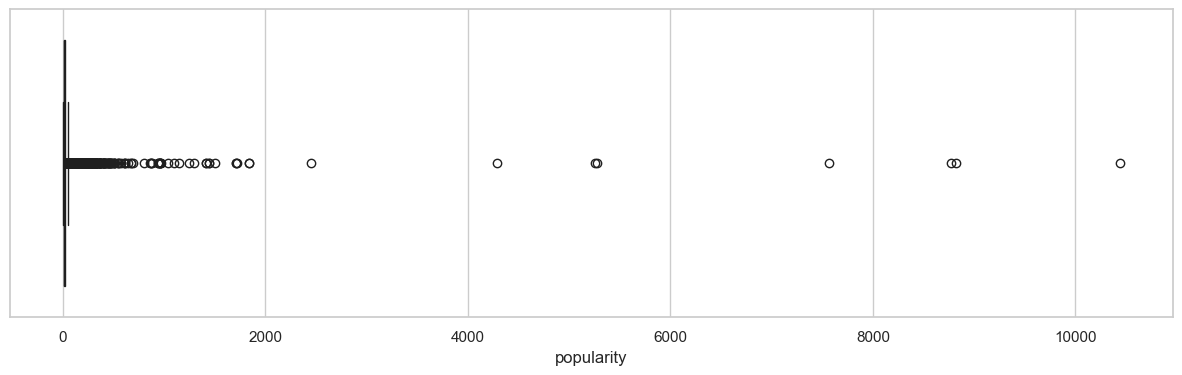

In [36]:
plt.figure(figsize=(15, 4))
sns.boxplot(data=df, x="popularity")

<Axes: xlabel='popularity'>

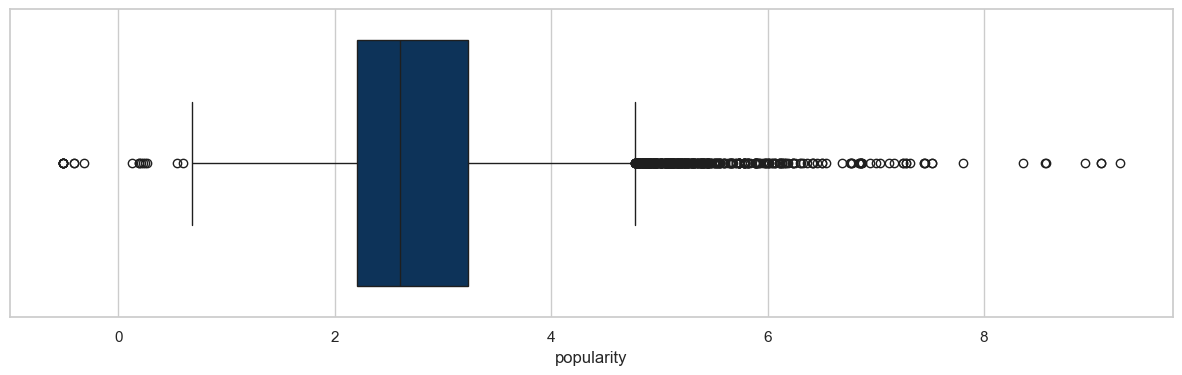

In [37]:
df_log = df.copy()
df_log["popularity"] = df_log["popularity"].apply(np.log)
plt.figure(figsize=(15, 4))
sns.boxplot(data=df_log, x="popularity")

In [38]:
def count_outliers(df):
    if "popularity" in df.columns:
        Q1 = df["popularity"].quantile(0.25)
        Q3 = df["popularity"].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        n_lower = (df["popularity"] < lower_bound).sum()
        n_upper = (df["popularity"] > upper_bound).sum()
        n_total = len(df)

        print(f"N Lower: {n_lower}")
        print(f"N Upper: {n_upper}")
        print(f"N Total: {n_total}")
        print(f"Persentase outliers: {round((n_lower + n_upper) / n_total * 100, 2)}%")

print("Raw Data:")
count_outliers(df)

print("\nLog Data:")
count_outliers(df_log)

Raw Data:
N Lower: 0
N Upper: 1511
N Total: 12999
Persentase outliers: 11.62%

Log Data:
N Lower: 19
N Upper: 430
N Total: 12999
Persentase outliers: 3.45%


Berikut adalah distribusi popularitas dalam log scale

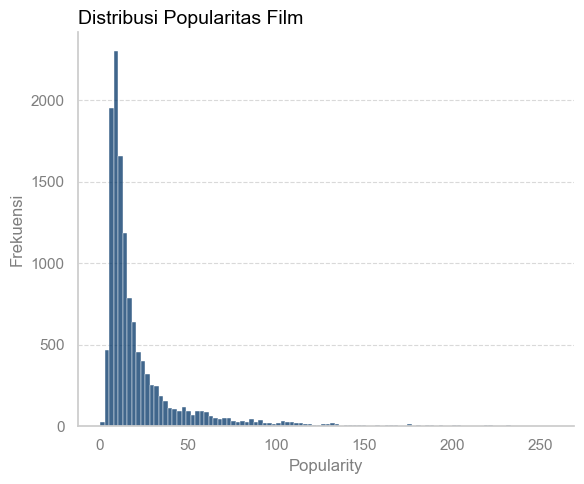

In [40]:
MCK_PALETTE = {
    "dark_blue":  "#003366",
    "medium_blue":"#1F77B4",
    "light_blue": "#6BAED6",
    "grey":       "#7F7F7F",
    "light_grey": "#D9D9D9",
    "black":      "#000000",
}

sns.set_theme(style="whitegrid")

df_pop = df[df["popularity"] <= df["popularity"].quantile(0.99)]

fig, ax = plt.subplots(figsize=(6,5))
sns.histplot(
    df_pop["popularity"],
    bins=100,
    color=MCK_PALETTE["dark_blue"],
    edgecolor="white",
    ax=ax
)

ax.set_title("Distribusi Popularitas Film", fontsize=14, loc="left", color=MCK_PALETTE["black"])
ax.set_xlabel("Popularity", fontsize=12, color=MCK_PALETTE["grey"])
ax.set_ylabel("Frekuensi", fontsize=12, color=MCK_PALETTE["grey"])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", color=MCK_PALETTE["light_grey"], linestyle="--", linewidth=0.8)
ax.grid(axis="x", visible=False)

ax.tick_params(axis="x", colors=MCK_PALETTE["grey"])
ax.tick_params(axis="y", colors=MCK_PALETTE["grey"])

plt.tight_layout()
plt.savefig("../image/distribusi_popularitas_film.png", dpi=150)
plt.show()


Berdasarkan tahun rilis, popularitas film adalah sebagai berikut

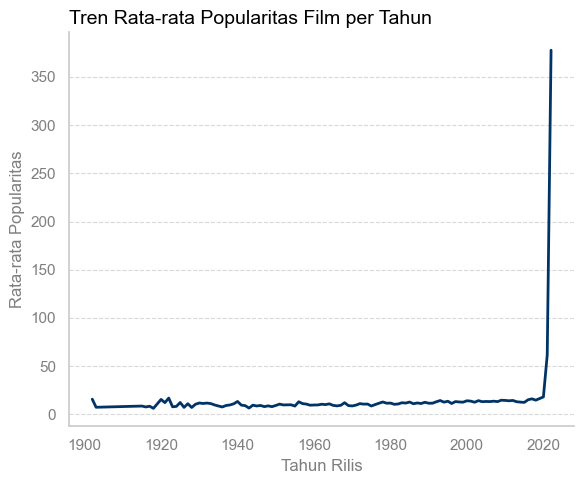

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

MCK_PALETTE = {
    "dark_blue":  "#003366",
    "medium_blue":"#1F77B4",
    "light_blue": "#6BAED6",
    "grey":       "#7F7F7F",
    "light_grey": "#D9D9D9",
    "black":      "#000000",
}

sns.set_theme(style="whitegrid")

df_time = df.copy()
df_time["release_date"] = pd.to_datetime(df_time["release_date"], errors="coerce")
df_time["release_year"] = df_time["release_date"].dt.year

trend = df_time.groupby("release_year")["popularity"].median().reset_index()

fig, ax = plt.subplots(figsize=(6,5))
sns.lineplot(
    data=trend,
    x="release_year",
    y="popularity",
    color=MCK_PALETTE["dark_blue"],
    linewidth=2,
    ax=ax
)

ax.set_title("Tren Rata-rata Popularitas Film per Tahun", fontsize=14, loc="left", color=MCK_PALETTE["black"])
ax.set_xlabel("Tahun Rilis", fontsize=12, color=MCK_PALETTE["grey"])
ax.set_ylabel("Rata-rata Popularitas", fontsize=12, color=MCK_PALETTE["grey"])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Grid horizontal saja
ax.grid(axis="y", color=MCK_PALETTE["light_grey"], linestyle="--", linewidth=0.8)
ax.grid(axis="x", visible=False)

# Tick label warna abu
ax.tick_params(axis="x", colors=MCK_PALETTE["grey"])
ax.tick_params(axis="y", colors=MCK_PALETTE["grey"])

plt.tight_layout()
plt.savefig("../image/tren_popularitas_per_tahun.png", dpi=150)
plt.show()


# Data Cleaning, Preprocessing, and Feature Engineering

### Missing Values (Summary)

Dengan jumlah missing value yang rendah pada fitur summary, mari kita teliti lebih lanjut seluruh baris dengan missing values pada fitur summary

In [46]:
df[df["summary"].isna()]

,movie_title,genre_label,language,summary,popularity,release_date
139,Tanguy,Comedy,fr,NaN,5.449,2001-11-21
610,Would I Lie to You? 2,Comedy,fr,NaN,4.741,2001-02-07
7302,"Amore, bugie e calcetto",NaN,en,NaN,4.709,2008-04-04
8537,Nati stanchi,Comedy,it,NaN,5.671,2002-03-01
10503,Would I Lie to You? 2,Comedy,fr,NaN,4.741,2001-02-07


Karena tampak tidak terdapat anomali atau informasi yang begitu berharga, maka akan aman untuk didrop seluruhnya

In [48]:
df_clean = df.dropna(subset=["summary"])

In [49]:
df_clean.shape

(12994, 6)

### Missing Values ("xx" pada Language) and Language Mapping

Berdasarkan penemuan sebelumnya, dilakukan mapping alias-alias yang ada

In [52]:
alias_mapping = {
    'cn': 'zh',
    'sh': 'sr'
}

df_clean["language"] = df["language"].map(lambda x: alias_mapping.get(x, x))

C:\Users\omgit\AppData\Local\Temp\ipykernel_30132\1414036907.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["language"] = df["language"].map(lambda x: alias_mapping.get(x, x))


Sudah tidak ada lagi alias bahasa yang redundan

In [54]:
df_clean[(df_clean["language"] == "cn") | (df_clean["language"] == "sh")]

,movie_title,genre_label,language,summary,popularity,release_date


Kini sudah tidak ada juga bahasa "unknown"

In [56]:
df_clean = df_clean.drop(df_clean[df_clean["language"] == "xx"].index)

In [57]:
df_clean[df_clean["language"] == "xx"]

,movie_title,genre_label,language,summary,popularity,release_date


### Duplicate Data

Ternyata terdapat banyak sekali baris  fitur yang merupakan duplikat (23,4%)

In [60]:
print(f"Jumlah duplikasi: {df.duplicated().sum()}")
print(f"Persentase duplikasi: {df.duplicated().sum()/df.shape[0]*100:.2f}%")

Jumlah duplikasi: 3008
Persentase duplikasi: 23.14%


Mari kita drop seluruh baris yang merupakan duplikat dan mengecek kembali dataset

In [62]:
df_clean = df_clean.drop_duplicates()

In [63]:
df_clean.shape

(9986, 6)

Dataset sudah bersih dari duplikat

In [65]:
df_clean.duplicated().sum()

0

### Date Parsing

Untuk memudahkan pemrosesan dan pemodelan serta agar sistem komputasi mengetahui bahwa konten pada release_date merupakan tanggal, akan dilakuakn parsing pada fitur ini. Tampak bahwa format yang digunakan adalah %Y-%m-%d.

In [68]:
df["release_date"].sample(5)

5855     2002-01-16
11825    2006-10-19
11597    2006-12-03
11304    2019-07-18
3857     2004-02-27
Name: release_date, dtype: object

In [69]:
df_clean["release_date"] = pd.to_datetime(df["release_date"], format="%Y-%m-%d")

Tampak kini fitur release_date sudah memiliki type datetime

In [71]:
df_clean["release_date"].head(1)

0   1995-11-10
Name: release_date, dtype: datetime64[ns]

Akan dibuat juga fitur release_year, relase_month, dan release_day untuk penelitian lebih lanjut terhadap komponen tanggal spesifik

In [73]:
df_clean["release_year"]  = df_clean["release_date"].dt.year
df_clean["release_month"] = df_clean["release_date"].dt.month
df_clean["release_day"]   = df_clean["release_date"].dt.day

In [74]:
df_clean.sample(1)

,movie_title,genre_label,language,summary,popularity,release_date,release_year,release_month,release_day
5604,No Escape,"Action,Drama,Science Fiction,Thriller",en,"In the year 2022, a ruthless prison warden has...",9.554,1994-04-29,1994,4,29


Berdasarkan bulan dan tahun, dapat juga dibuat fitur "release_season" dan "release_decade"

In [76]:
df_clean["release_decade"] = df_clean["release_year"].apply(lambda x: x // 10 * 10)

In [77]:
def get_season(month):
    if month in [12, 1, 2]: return 'winter'
    elif month in [3, 4, 5]: return 'spring'
    elif month in [6, 7, 8]: return 'summer'
    else: return 'fall'
df_clean['release_season'] = df_clean['release_month'].apply(get_season)

Karena tidak ada outlier pada release_year, maka tidak diperlukan preprocessing lebih lanjut

In [79]:
print(f"Tahun release paling early: {min(df_clean["release_year"])}")

Tahun release paling early: 1902


### Missing Values (Genre)

Kini seluruh baris pada dataset sudah tidak memiliki duplikat dan missing values pada fitur summary, serta tanggal (date) yang sudah di-parsing. Untuk mengisi seluruh missing values pada Genre, akan digunakan sebuah metode NLP untuk memprediksi genre berdasarkan summary

In [82]:
def run_sbert_lr_knn_blend(
    df,
    model_name="all-MiniLM-L6-v2",
    batch_size=128,
    C_grid=(0.5, 1.0, 2.0),
    alpha=0.7,
    k_neighbors=30,
    cap_max=4,
    verbose=True,
):
    # Clean labels
    df = df.copy()
    df["genre_label"] = df["genre_label"].fillna("").apply(lambda x: [g.strip() for g in x.split(",")] if x != "" else [])

    known_mask = df["genre_label"].apply(len) > 0
    unk_mask   = ~known_mask
    if verbose:
        print(f"Known: {known_mask.sum()}  |  Unknown: {unk_mask.sum()}")

    # Label space from KNOWN rows
    all_labels = sorted({g for lst in df.loc[known_mask, "genre_label"] for g in lst})
    mlb = MultiLabelBinarizer(classes=all_labels)
    y_known = mlb.fit_transform(df.loc[known_mask, "genre_label"])
    if verbose:
        print(f"# Unique genres: {len(all_labels)}")

    # SBERT embeddings
    sb = SentenceTransformer(model_name)
    texts_all = df["summary"].tolist()
    E_all = sb.encode(
        texts_all, batch_size=batch_size, normalize_embeddings=True, show_progress_bar=verbose
    )

    X_known = E_all[known_mask.values]
    X_unk   = E_all[unk_mask.values]

    idx_known = df.index[known_mask].to_numpy()
    idx_unk   = df.index[unk_mask].to_numpy()

    # --- Train/val split
    pos_all = np.arange(X_known.shape[0])
    pos_tr, pos_va = train_test_split(pos_all, test_size=0.2, random_state=42)
    X_tr, X_va = X_known[pos_tr], X_known[pos_va]
    y_tr, y_va = y_known[pos_tr], y_known[pos_va]

    # --- Helper funcs
    def tune_per_label_thresholds(y_true, y_prob, grid=None):
        if grid is None:
            grid = np.linspace(0.2, 0.7, 11)
        L = y_true.shape[1]
        thr = np.full(L, 0.5, dtype=np.float32)
        for j in range(L):
            best_f1, best_t = -1.0, 0.5
            pj, yj = y_prob[:, j], y_true[:, j]
            for t in grid:
                pred = (pj >= t).astype(int)
                f1   = f1_score(yj, pred, average="binary", zero_division=0)
                if f1 > best_f1:
                    best_f1, best_t = f1, t
            thr[j] = best_t
        return thr

    def binarize_with_thr(P, thr):
        return (P >= thr.reshape(1, -1)).astype(int)

    # Train LR + tune thresholds
    best_lr = {"score": -1, "C": None, "clf": None, "thr": None}
    for C in C_grid:
        clf_tmp = OneVsRestClassifier(
            LogisticRegression(solver="lbfgs", max_iter=1000, C=C, class_weight="balanced")
        )
        clf_tmp.fit(X_tr, y_tr)
        probs_va_tmp = clf_tmp.predict_proba(X_va)
        thr_tmp = tune_per_label_thresholds(y_va, probs_va_tmp)
        pred_va_tmp = binarize_with_thr(probs_va_tmp, thr_tmp)
        micro = f1_score(y_va, pred_va_tmp, average="micro", zero_division=0)
        if micro > best_lr["score"]:
            best_lr.update({"score": micro, "C": C, "clf": clf_tmp, "thr": thr_tmp})

    clf = best_lr["clf"]
    if verbose:
        print(f"[LR] Selected C={best_lr['C']} | Val Micro-F1={best_lr['score']:.3f}")

    # kNN neighbor scores
    K_NEI = k_neighbors
    nn = NearestNeighbors(n_neighbors=K_NEI, metric="cosine")
    nn.fit(X_known)
    L = y_known.shape[1]

    def knn_scores_vs_known(Emb_rows, drop_self_idx=None):
        dist, nbr = nn.kneighbors(Emb_rows, return_distance=True)
        sim = 1.0 - dist
        scores = np.zeros((Emb_rows.shape[0], L), dtype=float)
        for i, (row_sim, row_idx) in enumerate(zip(sim, nbr)):
            if drop_self_idx is not None:
                keep = [(s, j) for s, j in zip(row_sim, row_idx) if j != drop_self_idx[i]]
                if len(keep) == 0:
                    keep = list(zip(row_sim, row_idx))
                row_sim, row_idx = zip(*keep)
                row_sim = np.array(row_sim); row_idx = np.array(row_idx)
            w    = row_sim.reshape(-1, 1)
            lbls = y_known[row_idx]
            scores[i] = (lbls * w).sum(axis=0) / (w.sum() + 1e-9)
        return scores

    pos_va = np.array(pos_va)
    scores_kn_va          = knn_scores_vs_known(X_va, drop_self_idx=pos_va)
    scores_kn_all_known   = knn_scores_vs_known(X_known, drop_self_idx=np.arange(X_known.shape[0]))
    scores_kn_all_unknown = knn_scores_vs_known(X_unk, drop_self_idx=None) if X_unk.size else np.empty((0, L))

    # Blend
    probs_va = clf.predict_proba(X_va)
    blend_va = alpha * probs_va + (1 - alpha) * scores_kn_va

    expected_labels_per_row = y_tr.sum() / y_tr.shape[0]
    CAP = int(np.clip(np.round(expected_labels_per_row + 0.5), 1, cap_max))
    if verbose:
        print(f"Dynamic CAP: {expected_labels_per_row:.2f} → {CAP}")

    def cap_max_labels_by_prob(P, B, cap=CAP):
        out = B.copy()
        for i in range(out.shape[0]):
            k = out[i].sum()
            if k == 0:
                out[i, P[i].argmax()] = 1
            elif k > cap:
                ones = np.where(out[i] == 1)[0]
                keep = ones[np.argsort(P[i, ones])[-cap:]]
                row = np.zeros_like(out[i]); row[keep] = 1; out[i] = row
        return out

    thr_blend = tune_per_label_thresholds(y_va, blend_va, grid=np.linspace(0.2, 0.8, 25))
    pred_va   = binarize_with_thr(blend_va, thr_blend)
    pred_va   = cap_max_labels_by_prob(blend_va, pred_va, cap=CAP)

    if verbose:
        print("\nBLENDED (Val) metrics:")
        print("  Micro F1 :", f1_score(y_va, pred_va, average='micro', zero_division=0))
        print("  Macro F1 :", f1_score(y_va, pred_va, average='macro', zero_division=0))

    # Apply blend to ALL
    probs_known = clf.predict_proba(X_known)
    blend_known = alpha * probs_known + (1 - alpha) * scores_kn_all_known
    blend_known_bin = binarize_with_thr(blend_known, thr_blend)
    blend_known_bin = cap_max_labels_by_prob(blend_known, blend_known_bin, cap=CAP)

    if X_unk.size:
        probs_unk = clf.predict_proba(X_unk)
        blend_unk = alpha * probs_unk + (1 - alpha) * scores_kn_all_unknown
        blend_unk_bin = binarize_with_thr(blend_unk, thr_blend)
        blend_unk_bin = cap_max_labels_by_prob(blend_unk, blend_unk_bin, cap=CAP)
    else:
        blend_unk_bin = np.empty((0, L), dtype=int)

    # Attach predictions
    pred_labels_known = mlb.inverse_transform(blend_known_bin)
    df["genre_pred_sbert_blend"] = None
    df.loc[idx_known, "genre_pred_sbert_blend"] = pd.Series([list(x) for x in pred_labels_known],
                                                            index=idx_known, dtype="object")
    if len(idx_unk) > 0:
        pred_labels_unk = mlb.inverse_transform(blend_unk_bin)
        df.loc[idx_unk, "genre_pred_sbert_blend"] = pd.Series([list(x) for x in pred_labels_unk],
                                                              index=idx_unk, dtype="object")

    # relaxed match: SUBSET ONLY, at most 1 missing label ---
    def relaxed_subset_only(true_set, pred_set, max_missing=1):
        # count as relaxed match iff prediction is a subset of the true labels,
        # and it misses no more than `max_missing` labels
        return pred_set.issubset(true_set) and len(true_set - pred_set) <= max_missing
    
    # ---------- VALIDATION ----------
    true_sets_va = [set(lbls) for lbls in mlb.inverse_transform(y_va)]
    pred_sets_va = [set(lbls) for lbls in mlb.inverse_transform(pred_va)]
    
    exact_va = sum(1 for a, b in zip(true_sets_va, pred_sets_va) if a == b)
    relax_va = sum(1 for a, b in zip(true_sets_va, pred_sets_va) if (a == b) or relaxed_subset_only(a, b, max_missing=1))
    
    print(f"\n[VALIDATION] Exact matches:                 {exact_va}/{len(true_sets_va)} ({exact_va/len(true_sets_va):.1%})")
    print(f"[VALIDATION] Relaxed (subset-only, ≤1 miss): {relax_va}/{len(true_sets_va)} ({relax_va/len(true_sets_va):.1%})")
    
    # (optional) Jaccard stays the same if you still want it:
    def jaccard(a, b):
        u, i = a | b, a & b
        return len(i)/len(u) if len(u) else 1.0
    jacc_va = [jaccard(a,b) for a,b in zip(true_sets_va, pred_sets_va)]
    print(f"[VALIDATION] Jaccard — mean: {np.mean(jacc_va):.3f} | median: {np.median(jacc_va):.3f}")

    # ALL KNOWN
    true_sets_kn = [set(lbls) for lbls in mlb.inverse_transform(y_known)]
    pred_sets_kn = [set(lbls) for lbls in mlb.inverse_transform(blend_known_bin)]
    
    exact_kn = sum(1 for a, b in zip(true_sets_kn, pred_sets_kn) if a == b)
    relax_kn = sum(1 for a, b in zip(true_sets_kn, pred_sets_kn) if (a == b) or relaxed_subset_only(a, b, max_missing=1))
    
    print(f"\n[KNOWN] Exact matches:                      {exact_kn}/{len(true_sets_kn)} ({exact_kn/len(true_sets_kn):.1%})")
    print(f"[KNOWN] Relaxed (subset-only, ≤1 miss):     {relax_kn}/{len(true_sets_kn)} ({relax_kn/len(true_sets_kn):.1%})")

    df["final_genre"] = None
    df.loc[known_mask, "final_genre"] = df.loc[known_mask, "genre_label"].apply(lambda x: list(x) if isinstance(x, (list, tuple, set)) else ([] if pd.isna(x) else [x]))
    df.loc[unk_mask,   "final_genre"] = df.loc[unk_mask,   "genre_pred_sbert_blend"].apply(lambda x: list(x) if isinstance(x, (list, tuple, set)) else ([] if x is None else [x]))
    
    # Sanity: ensure dtype object and lists
    df["final_genre"] = df["final_genre"].apply(lambda x: x if isinstance(x, list) else ([] if x is None else [x]))
    df["genre_label"] = df["final_genre"].apply(lambda x: ",".join(x))
    print("\n[INFO] df['final_genre'] created. Sample:")
    
    df = df.drop(labels=['genre_pred_sbert_blend', 'final_genre'], axis = 1)

    return df

In [83]:
df_clean = run_sbert_lr_knn_blend(df_clean, model_name="all-MiniLM-L6-v2", verbose=True)

Known: 7987  |  Unknown: 1999
# Unique genres: 18


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

[LR] Selected C=0.5 | Val Micro-F1=0.604
Dynamic CAP: 2.58 → 3

BLENDED (Val) metrics:
  Micro F1 : 0.6143336529242569
  Macro F1 : 0.5641785568606673

[VALIDATION] Exact matches:                 186/1598 (11.6%)
[VALIDATION] Relaxed (subset-only, ≤1 miss): 347/1598 (21.7%)
[VALIDATION] Jaccard — mean: 0.484 | median: 0.500

[KNOWN] Exact matches:                      1059/7987 (13.3%)
[KNOWN] Relaxed (subset-only, ≤1 miss):     1827/7987 (22.9%)

[INFO] df['final_genre'] created. Sample:


In [84]:
df_clean.head(5)

,movie_title,genre_label,language,summary,popularity,release_date,release_year,release_month,release_day,release_decade,release_season
0,Ace Ventura: When Nature Calls,"Crime,Comedy,Adventure",en,"Summoned from an ashram in Tibet, Ace finds hi...",28.877,1995-11-10,1995,11,10,1990,fall
1,The Wave,Thriller,no,"Although theorised, no one is really ready whe...",28.675,2015-08-28,2015,8,28,2010,summer
2,Spotlight,"Drama,Thriller",en,The true story of how the Boston Globe uncover...,13.601,2015-11-06,2015,11,6,2010,fall
3,The Medallion,"Thriller,Fantasy,Action,Comedy",en,A Hong Kong detective suffers a fatal accident...,17.180,2003-08-15,2003,8,15,2000,summer
4,Caro diario,"Comedy,Drama",it,Nanni Moretti recalls in his diary three slice...,6.270,1993-10-12,1993,10,12,1990,fall


### Genre Preprocessing and Feature Engineering

Untuk memudahkan pemrosesan dan pemodelan, akan dibuat fitur genre_count (jumlah genre film), serta pembuatan dummies binary untuk masing-masing genre, misal movie dengan genre horror dan action akan memiliki value 1 pada is_horror dan is_action. 

In [87]:
df["genre_label"].sample(10)

11678                                 NaN
11332    Comedy,Action,Adventure,Thriller
9598                         Comedy,Drama
9779                                  NaN
7895                                Drama
4309                         Comedy,Music
6502        Adventure,Family,Drama,Comedy
5820                                Drama
2657                                  NaN
4767                    Drama,History,War
Name: genre_label, dtype: object

In [88]:
def add_genre_count(df_input: pd.DataFrame, genre_col: str = "genre_label"):
    df = df_input.copy()
    s = df[genre_col]
    cnt = s.str.count(",") + 1
    df["genre_count"] = cnt.where(s.notna(), 0).astype("int16")
    return df

def add_genre_flags(
    df_input,
    genre_col = "genre_label",
    prefix = "is_",
):
    df = df_input.copy()
    dummies = (
        df[genre_col]
        .fillna("")             
        .str.get_dummies(sep=",")
    )
    dummies.columns = [
        f"{prefix}{c.strip().replace(' ', '_').lower()}" for c in dummies.columns
    ]
    dummies = dummies.astype("int8")
    df = pd.concat([df, dummies], axis=1)
    return df

In [89]:
df_clean = add_genre_count(df_clean)
df_clean = add_genre_flags(df_clean)
df_clean = df_clean.drop(labels=["genre_label"], axis=1)

In [90]:
df_clean.head()

,movie_title,language,summary,popularity,release_date,release_year,release_month,release_day,release_decade,release_season,genre_count,is_action,is_adventure,is_animation,is_comedy,is_crime,is_drama,is_family,is_fantasy,is_history,is_horror,is_music,is_mystery,is_romance,is_science_fiction,is_tv_movie,is_thriller,is_war,is_western
0,Ace Ventura: When Nature Calls,en,"Summoned from an ashram in Tibet, Ace finds hi...",28.877,1995-11-10,1995,11,10,1990,fall,3,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,The Wave,no,"Although theorised, no one is really ready whe...",28.675,2015-08-28,2015,8,28,2010,summer,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,Spotlight,en,The true story of how the Boston Globe uncover...,13.601,2015-11-06,2015,11,6,2010,fall,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
3,The Medallion,en,A Hong Kong detective suffers a fatal accident...,17.180,2003-08-15,2003,8,15,2000,summer,4,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0
4,Caro diario,it,Nanni Moretti recalls in his diary three slice...,6.270,1993-10-12,1993,10,12,1990,fall,2,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0


### Data Cleaning, Preprocessing, and Feature Engineering Pipeline

In [92]:
def clean_data(df_input):
    df = df_input.copy()

    # Drop missing values (summary)
    df = df.dropna(subset=["summary"])

    # language "xx" and mapping
    df = df.drop(df[df["language"] == "xx"].index)
    alias_mapping = {
        'cn': 'zh',
        'sh': 'sr'
    }
    df["language"] = df["language"].map(lambda x: alias_mapping.get(x, x))
    
    # Handle duplicates
    df = df.drop_duplicates()

    # Date parsing and feature enginneering
    df["release_date"]   = pd.to_datetime(df["release_date"], format="%Y-%m-%d")
    df["release_year"]   = df["release_date"].dt.year
    df["release_month"]  = df["release_date"].dt.month
    df["release_day"]    = df["release_date"].dt.day
    df["release_decade"] = df["release_year"].apply(lambda x: x // 10 * 10)

    def get_season(month):
        if month in [12, 1, 2]: return 'winter'
        elif month in [3, 4, 5]: return 'spring'
        elif month in [6, 7, 8]: return 'summer'
        else: return 'fall'
    df['release_season'] = df['release_month'].apply(get_season)

    # Genre preprocessing and feature engineering
    def add_genre_count(df_input: pd.DataFrame, genre_col: str = "genre_label"):
        df = df_input.copy()
        s = df[genre_col]
        cnt = s.str.count(",") + 1
        df["genre_count"] = cnt.where(s.notna(), 0).astype("int16")
        return df
    
    def add_genre_flags(
        df_input,
        genre_col = "genre_label",
        prefix = "is_",
    ):
        df = df_input.copy()
        dummies = (
            df[genre_col]
            .fillna("")             
            .str.get_dummies(sep=",")
        )
        dummies.columns = [
            f"{prefix}{c.strip().replace(' ', '_').lower()}" for c in dummies.columns
        ]
        dummies = dummies.astype("int8")
        df = pd.concat([df, dummies], axis=1)
        return df

    # Fill missing values (genre)
    df = run_sbert_lr_knn_blend(df, model_name="all-MiniLM-L6-v2", verbose=True)

    # Add genre count and convert to flags
    df = add_genre_count(df)
    df = add_genre_flags(df)
    df = df.drop(labels=["genre_label"], axis=1)


    print(f"Missing values:\n{df.isna().sum()}\n")
    print(f"Duplicated values: {df.duplicated().sum()}")
    
    return df


In [93]:
data = clean_data(df)

Known: 7987  |  Unknown: 1999
# Unique genres: 18


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

[LR] Selected C=0.5 | Val Micro-F1=0.604
Dynamic CAP: 2.58 → 3

BLENDED (Val) metrics:
  Micro F1 : 0.6143336529242569
  Macro F1 : 0.5641785568606673

[VALIDATION] Exact matches:                 186/1598 (11.6%)
[VALIDATION] Relaxed (subset-only, ≤1 miss): 347/1598 (21.7%)
[VALIDATION] Jaccard — mean: 0.484 | median: 0.500

[KNOWN] Exact matches:                      1059/7987 (13.3%)
[KNOWN] Relaxed (subset-only, ≤1 miss):     1827/7987 (22.9%)

[INFO] df['final_genre'] created. Sample:
Missing values:
movie_title           0
language              0
summary               0
popularity            0
release_date          0
release_year          0
release_month         0
release_day           0
release_decade        0
release_season        0
genre_count           0
is_action             0
is_adventure          0
is_animation          0
is_comedy             0
is_crime              0
is_drama              0
is_family             0
is_fantasy            0
is_history            0
is_horror 

In [94]:
data.sample(5)

,movie_title,language,summary,popularity,release_date,release_year,release_month,release_day,release_decade,release_season,genre_count,is_action,is_adventure,is_animation,is_comedy,is_crime,is_drama,is_family,is_fantasy,is_history,is_horror,is_music,is_mystery,is_romance,is_science_fiction,is_tv_movie,is_thriller,is_war,is_western
3184,Halloween,en,"After being committed for 17 years, Michael My...",43.172,2007-08-31,2007,8,31,2000,summer,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
10580,Imperium,en,"Nate Foster, a young, idealistic FBI agent, go...",17.075,2016-08-19,2016,8,19,2010,summer,4,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0
6450,Eagle Eye,en,Jerry Shaw and Rachel Holloman are two strange...,16.199,2008-09-25,2008,9,25,2000,fall,3,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
6833,Time Bandits,en,Young history buff Kevin can scarcely believe ...,13.665,1981-07-13,1981,7,13,1980,summer,5,0,1,0,1,0,0,1,1,0,0,0,0,0,1,0,0,0,0
108,The Man Who Knew Too Little,en,An American gets a ticket for an audience part...,6.930,1997-11-14,1997,11,14,1990,fall,3,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [95]:
data.to_csv("../data/processed_data_ifest.csv", index=False)

# Insights Extraction

In [97]:
data = pd.read_csv("../data/processed_data_ifest.csv")

### Business Question 1: Bagaimana efek jumlah genre terhadap popularitas dengan kontrol confounding tahun/bahasa?

##### Hypothesis: Media popularity score berbanding lurus (positive correlation) genre_count.

Metode: (1) Spearman Rank Correlation (untuk mengukur arah dan kekuatan korelasi monotonic antara dua variabel ranking yang bukan merupakan asli seperti popularity), (2) Mann-Whitney U Test untuk mengukur apakah perbedaan antara 1-genre vs multi-genre signifikan, dan (3) Stratifikasi data per tahun dan per bahasa

Berikut adalah eksperimen Spearman Rank Correlation dengan confounding bahasa Inggris dan release year 2000

In [102]:
data_en_2018 = data[(data["language"] == "en") & (data["release_year"] == 2018)]

In [103]:
print(f"Jumlah movie dengan 1 genre_count: {data_en_2018[data_en_2018["genre_count"] == 1].count()["movie_title"]}")
print(f"Jumlah movie dengan lebih dari 1 genre_count: {data_en_2018[data_en_2018["genre_count"] > 1].count()["movie_title"]}")

Jumlah movie dengan 1 genre_count: 37
Jumlah movie dengan lebih dari 1 genre_count: 297


In [104]:
rho, pval = spearmanr(data_en_2018["genre_count"], data_en_2018["popularity"])

print(f"Spearman correlation (ρ): {rho:.3f}")
print(f"P-value: {pval:.3g}")

Spearman correlation (ρ): 0.240
P-value: 8.84e-06


Pada tahun 2018 dan film berbahasa Inggris, jumlah genre_count berpengaruh secara signifikan. Bagaimana dengan film berbahasa Inggris pada tahun 2000?

In [106]:
data_en_2000 = data[(data["language"] == "en") & (data["release_year"] == 2000)]

In [107]:
print(f"Jumlah movie dengan 1 genre_count: {data_en_2000[data_en_2000["genre_count"] == 1].count()["movie_title"]}")
print(f"Jumlah movie dengan lebih dari 1 genre_count: {data_en_2000[data_en_2000["genre_count"] > 1].count()["movie_title"]}")

Jumlah movie dengan 1 genre_count: 16
Jumlah movie dengan lebih dari 1 genre_count: 123


In [108]:
rho, pval = spearmanr(data_en_2000["genre_count"], data_en_2000["popularity"])

print(f"Spearman correlation (ρ): {rho:.3f}")
print(f"P-value: {pval:.3g}")

Spearman correlation (ρ): 0.024
P-value: 0.776


Ternyata hasilnya tidak signifikan, mari kita lihat lebih jauh bagaimana pengaruh genre_count ini dengan film berbahasa Inggris pada tahun 1950 - 2018

In [110]:
year_start, year_end = 1950, 1990

In [111]:
spearman = []
p_value = []
years = []

positive_corr_counter, strong_corr_counter = 0, 0

for year in np.arange(year_start, year_end+1):
    data_confounding = data[(data["language"] == "en") & (data["release_year"] == year)]
    if len(data_confounding) > 1:  # butuh minimal 2 sampel
        rho, pval = spearmanr(data_confounding["genre_count"], data_confounding["popularity"])
    else:
        rho, pval = np.nan, np.nan

    spearman.append(rho)
    p_value.append(pval)
    years.append(year)

    if (rho > 0):
        positive_corr_counter += 1
    if (pval < 0.05):
        strong_corr_counter += 1

# Buat DataFrame
df_spearman = pd.DataFrame({
    "year": years,
    "spearman_rho": spearman,
    "p_value": p_value
})
df_spearman["significant"] = df_spearman["p_value"] < 0.05

mean_rho = df_spearman["spearman_rho"].mean(skipna=True)
median_rho = df_spearman["spearman_rho"].median(skipna=True)
mean_p = df_spearman["p_value"].mean(skipna=True)
median_p = df_spearman["p_value"].median(skipna=True)

print(f"\nPositive correlation (out of {year_end-year_start+1}): {positive_corr_counter}")
print(f"Strong correlation (out of {year_end-year_start+1}): {strong_corr_counter}")
print(f"Mean Spearman ρ   : {mean_rho:.3f}")
print(f"Median Spearman ρ : {median_rho:.3f}")
print(f"Mean p-value      : {mean_p:.3f}")
print(f"Median p-value    : {median_p:.3f}")


Positive correlation (out of 41): 25
Strong correlation (out of 41): 3
Mean Spearman ρ   : 0.073
Median Spearman ρ : 0.087
Mean p-value      : 0.486
Median p-value    : 0.496


Berdasarkan perhitungan di atas dan grafik di bawah, tampak bahwa pada seluruh tahun 1990-2018 terdapat korelasi positif antara genre_count dengan popularity, di mana hampir 50% di antaranya memiliki korelasi yang kuat/signifikan. Namun, korelasi pada era modern (1990-2018) tidak selalu terjadi pada era sebelum tahun 1990, di mana korelasi antara genre_count dengan popularity dapat menjadi tidak menentu. Hasil ini mengindikasikan bahwa film multi-genre cenderung lebih populer pada era modern ketika pasar film semakin global, namun tidak dengan pada era pra-modern.

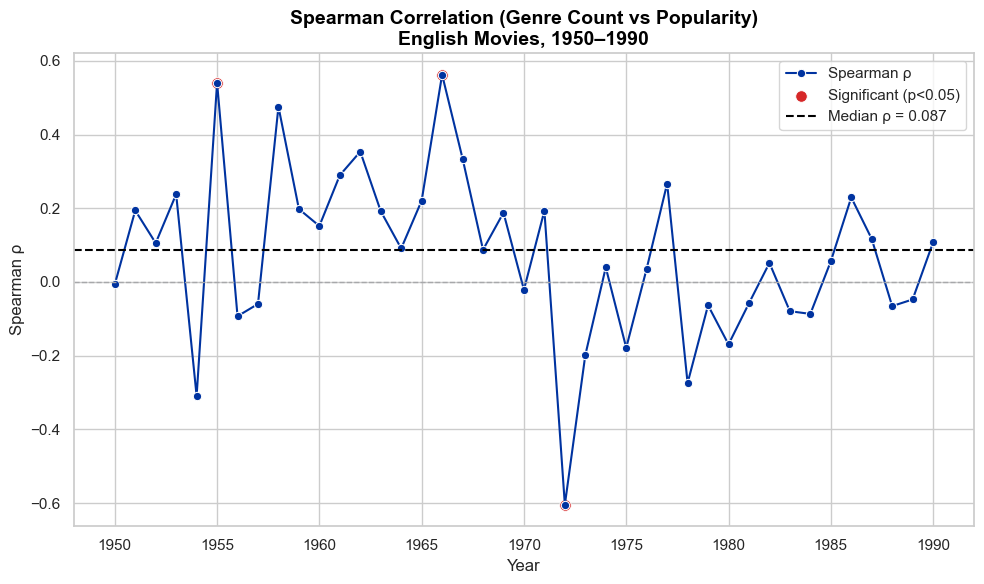

In [113]:
mck_blue = "#0033A0"      # garis utama
mck_red = "#D62728"       # titik signifikan
mck_gray = "#A7A8AA"      # garis referensi
mck_black = "#000000"     # highlight

plt.figure(figsize=(10,6))

# Garis utama
sns.lineplot(
    data=df_spearman, x="year", y="spearman_rho",
    marker="o", color=mck_blue, label="Spearman ρ"
)

# Titik signifikan merah
sns.scatterplot(
    data=df_spearman[df_spearman["significant"]],
    x="year", y="spearman_rho",
    color=mck_red, s=70, label="Significant (p<0.05)"
)

# Garis nol
plt.axhline(0, color=mck_gray, linestyle="--", linewidth=1)

# Garis median
plt.axhline(
    median_rho, color=mck_black, linestyle="--", linewidth=1.5,
    label=f"Median ρ = {median_rho:.3f}"
)

plt.title(
    f"Spearman Correlation (Genre Count vs Popularity)\nEnglish Movies, {year_start}–{year_end}",
    fontsize=14, weight="bold", color=mck_black
)
plt.ylabel("Spearman ρ")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.savefig("../image/spearman_genre_count.png", dpi=150)
plt.show()


Kini, akan dilakukan eksperimen Mann-Whitney U Test untuk menguji signifikan perbedaan single genre dengan multi genre

In [115]:
def mw_one_year(df, year, lang="en"):
    sub = df[(df["language"]==lang) & (df["release_year"]==year)].dropna(subset=["genre_count","popularity"])
    g1 = sub.loc[sub["genre_count"]==1, "popularity"].to_numpy()
    g2 = sub.loc[sub["genre_count"]>=2, "popularity"].to_numpy()

    n1, n2 = len(g1), len(g2)
    if n1<5 or n2<5:
        return {"year":year, "n1":n1, "n2":n2, "U":np.nan, "p":np.nan, "r_rb":np.nan, "r_z":np.nan}

    # two-sided by default
    U, p = mannwhitneyu(g1, g2, alternative="two-sided", method="auto")

    # effect size 1: rank-biserial correlation (skala -1..+1; positif = grup2 > grup1)
    r_rb = 1 - (2*U)/(n1*n2)

    # effect size 2: |z|/sqrt(N) (Cohen's r). z aproximated from U
    mu_U = n1*n2/2
    sigma_U = np.sqrt(n1*n2*(n1+n2+1)/12)
    z = (U - mu_U)/sigma_U
    r_z = abs(z) / np.sqrt(n1+n2)

    return {"year":year, "n1":n1, "n2":n2, "U":U, "p":p, "r_rb":r_rb, "r_z":r_z}

res_2018 = mw_one_year(data, year=2018, lang="en")
res_2018

{'year': 2018,
 'n1': 37,
 'n2': 297,
 'U': 3770.0,
 'p': 0.001854331441568925,
 'r_rb': 0.31385931385931387,
 'r_z': 0.1703644980870126}

Pada film yang di-release tahun 2018 dan berbahasa Inggris sendiri, tampak terdapat perbedaan signifikan (p < 0.01) di mana film dengan multi genre lebih popular dibandingkan single genre

In [117]:
def mw_yearly(df, year_start=1990, year_end=2022, lang="en"):
    rows = []
    for y in range(year_start, year_end+1):
        rows.append(mw_one_year(df, y, lang))
    out = pd.DataFrame(rows)
    # flag signifikan & arah efek
    out["significant"] = out["p"] < 0.05
    out["direction"]   = np.where(out["r_rb"]>0, "multi>single", "single>=multi")
    higher_multi_count = out[out["direction"] == "multi>single"].count()["direction"]
    return out, higher_multi_count

In [118]:
mw_en, higher_multi_count = mw_yearly(data, 1950, 1989, "en")
print(f"Multi > Single count: {higher_multi_count} out of {1989-1950+1}")

Multi > Single count: 4 out of 40


In [119]:
mw_en, higher_multi_count = mw_yearly(data, 1990, 2022, "en")
print(f"Multi > Single count: {higher_multi_count} out of {2022-1990+1}")

Multi > Single count: 27 out of 33


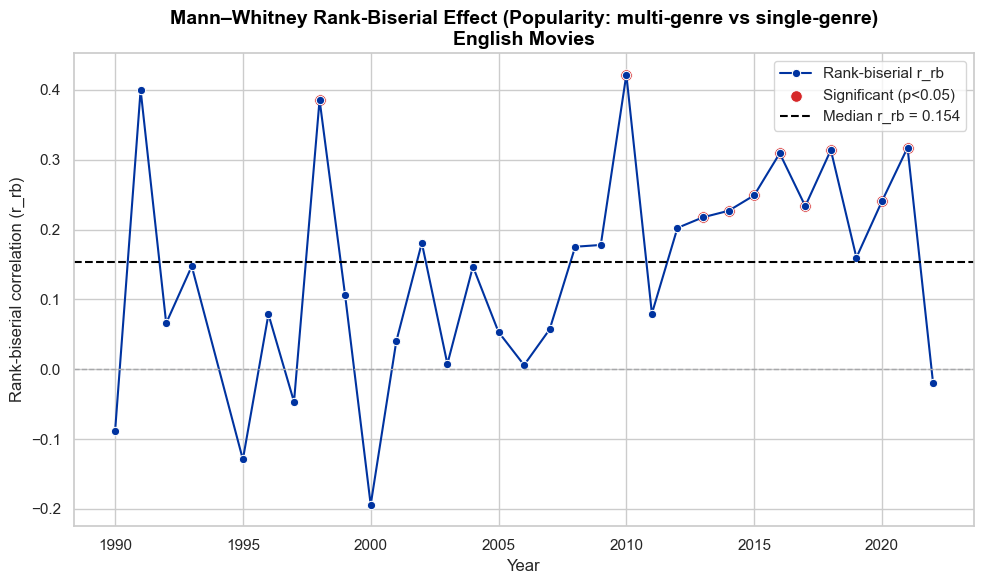

In [120]:
mck_blue = "#0033A0"      # garis utama
mck_red = "#D62728"       # titik signifikan (merah)
mck_gray = "#A7A8AA"      # garis referensi
mck_black = "#000000"     # highlight

plt.figure(figsize=(10,6))

sns.lineplot(
    data=mw_en, x="year", y="r_rb",
    marker="o", color=mck_blue, label="Rank-biserial r_rb"
)

sns.scatterplot(
    data=mw_en[mw_en["significant"]],
    x="year", y="r_rb", s=70,
    color=mck_red, label="Significant (p<0.05)"
)

plt.axhline(0, color=mck_gray, ls="--", lw=1)

median_rrb = mw_en["r_rb"].median()
plt.axhline(
    median_rrb, color=mck_black, ls="--", lw=1.5,
    label=f"Median r_rb = {median_rrb:.3f}"
)

plt.title(
    "Mann–Whitney Rank-Biserial Effect (Popularity: multi-genre vs single-genre)\nEnglish Movies",
    fontsize=14, weight="bold", color=mck_black
)
plt.ylabel("Rank-biserial correlation (r_rb)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.savefig("../image/t_test_genre_count.png", dpi=150)
plt.show()


Berdasarkan U Test di atas, hasil eksperimen Spearman diperkuat oleh Mann–Whitney U test, yang membandingkan langsung popularitas film single-genre vs multi-genre. Efek rank-biserial median sebesar 0.154 menunjukkan bahwa multi-genre memang memiliki distribusi popularitas lebih tinggi, meskipun efeknya tidak selalu signifikan di tiap tahun. Sejak 2010-an, efek positif ini semakin konsisten, memperlihatkan bahwa strategi multi-genre memberi keunggulan nyata.

Temuan ini masuk akal: di era industri film klasik, jumlah genre tidak banyak memengaruhi daya tarik, karena pasar lebih homogen dan distribusi terbatas. Namun di era modern dengan streaming dan audiens global, film dengan kombinasi 2–3 genre lebih mampu menjangkau segmen penonton yang lebih luas, sehingga memberikan dorongan popularitas yang lebih stabil dibanding single-genre.

### Business Question 2: Apakah seiring meningkatnya jumlah genre terdapat diminishing returns popularitas?

##### Hypothesis: Hanya terdapat efek positif kuat pada 3-5 tag pertama lalu mengalami diminishing return pada penambahan tag seterusnya.

Metode: Quantile Regression karena nature data dengan popularity yang skewed dan penuh dengan outlier, sehingga perhitungan kategori tidak berdasarkan estimator mean, melainkan quantile tertentu

                         QuantReg Regression Results                          
Dep. Variable:             popularity   Pseudo R-squared:             0.009847
Model:                       QuantReg   Bandwidth:                       3.323
Method:                 Least Squares   Sparsity:                        26.22
Date:                Tue, 30 Sep 2025   No. Observations:                 8309
Time:                        23:28:11   Df Residuals:                     8305
                                        Df Model:                            3
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                              10.5940      0.376     28.158      0.000       9.856      11.331
bs(genre_count, knots=(2, 5), degree=1,

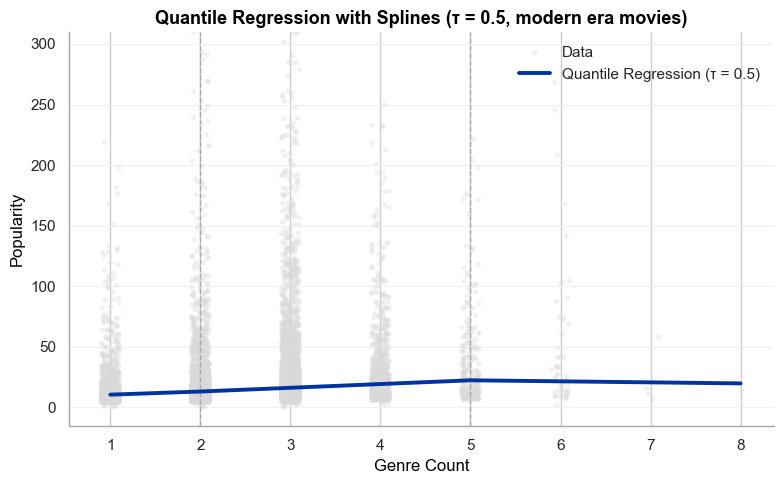

In [125]:
mck_blue   = "#0033A0"   # line
mck_gray   = "#A7A8AA"   # refs
mck_black  = "#000000"   # text
mck_silver = "#D9D9D9"   # scatter

df = data[data["release_year"] >= 1990].copy()
X = dmatrix("bs(genre_count, knots=(2,5), degree=1, include_intercept=False)",
            {"genre_count": df["genre_count"]}, return_type='dataframe')
mod = sm.QuantReg(df["popularity"], X)
res = mod.fit(q=0.5)
print(res.summary())

grid = np.arange(df["genre_count"].min(), df["genre_count"].max()+1)
Xg = dmatrix("bs(genre_count, knots=(2,5), degree=1, include_intercept=False)",
             {"genre_count": grid}, return_type='dataframe')
pred = res.predict(Xg)

USE_CLIP   = True  
CLIP_Q     = 0.99  
JITTER     = 0.10  

plt.figure(figsize=(8,5))

x_scatter = df["genre_count"] + np.random.uniform(-JITTER, JITTER, size=len(df))
plt.scatter(
    x_scatter, df["popularity"],
    color=mck_silver, edgecolor="none", alpha=0.35, s=14, label="Data"
)

plt.plot(grid, pred, color=mck_blue, linewidth=2.8, zorder=5,
         label="Quantile Regression (τ = 0.5)")

for k in (2, 5):
    plt.axvline(k, color=mck_gray, linestyle="--", linewidth=1)

ax = plt.gca()
if USE_CLIP:
    y_top = np.quantile(df["popularity"], CLIP_Q)
    ax.set_ylim(-0.05*y_top, y_top)  # sedikit ruang bawah
else:
    ax.set_yscale("symlog", linthresh=5, linscale=1)  # linear dekat 0, log utk besar
    ax.tick_params(axis='y', which='both', labelsize=9)

ax.set_facecolor("white")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["left", "bottom"]:
    ax.spines[s].set_color(mck_gray); ax.spines[s].set_linewidth(1)
ax.grid(True, axis="y", color="#EEEEEE", linewidth=1, alpha=0.8)

plt.xlabel("Genre Count", color=mck_black)
plt.ylabel("Popularity", color=mck_black)
plt.title("Quantile Regression with Splines (τ = 0.5, modern era movies)",
          fontsize=13, weight="bold", color=mck_black)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("../image/diminishing_genre_count.png", dpi=150)
plt.show()


Pada era modern, jumlah genre terbukti berhubungan positif dengan popularitas. Film dengan 3–5 genre mendapatkan peningkatan median popularitas yang signifikan (koefisien = 11.85, p < 0.001), sementara setelah 5 genre efeknya masih positif namun mulai melandai (koefisien = 9.29, p = 0.035) — indikasi diminishing returns

### Business Question 3: Dari seluruh fitur atau aspek yang menentukan popularity dari suatu movie, bagaimana urutan fitur dari yang paling penting?

##### Hypothesis: Tidak ada ekspektasi terhadap importance fitur tertentu, namun diekspektasikan tidak terdapat perbedaan yang signifikan antarfitur

Karena nature dari data yang skewed di mana range dari popularity sangat lebar, maka dilakukan log transform dan outlier trimming untuk mendapatkan hasil inference yang lebih akurat.

In [130]:
TARGET = "popularity"
TRIM_UPPER_Q = 0.99
APPLY_LOWER_TRIM = False
TRIM_LOWER_Q = 0.00

df = data.drop(labels=["release_date", "release_day", "summary", "movie_title"], axis=1).copy()
assert TARGET in df.columns, f"{TARGET} tidak ditemukan di processed_data_ifest.csv"

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in num_cols:
    num_cols.remove(TARGET)

cat_cols = [c for c in df.columns if (df[c].dtype == "object") and (df[c].nunique(dropna=False) <= 60)]

use_cols = num_cols + cat_cols + [TARGET]
df_use = df[use_cols].replace([np.inf, -np.inf], np.nan).dropna(how="any")

X_full = df_use.drop(columns=[TARGET])
y_full = df_use[TARGET].values

cat_idx = [X_full.columns.get_loc(c) for c in cat_cols]

def make_model():
    return CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        random_seed=42,
        verbose=False,
    )

def _get_fold_importance(model: CatBoostRegressor, feature_names: list) -> pd.DataFrame:
    imp = model.get_feature_importance(type="FeatureImportance")
    df_imp = pd.DataFrame({"feature": feature_names, "importance": imp})
    df_imp = df_imp.groupby("feature", as_index=False)["importance"].sum().sort_values("importance", ascending=False)
    return df_imp

def _aggregate_genre_language(df_imp_mean: pd.DataFrame) -> pd.DataFrame:
    df_imp = df_imp_mean.copy()
    df_imp["__group__"] = df_imp["feature"]
    df_imp.loc[df_imp["feature"].str.startswith("is_"), "__group__"] = "genre"
    df_imp.loc[df_imp["feature"].str.startswith("language_"), "__group__"] = "language"

    grouped = (df_imp.groupby("__group__", as_index=False)["importance"]
                    .sum()
                    .rename(columns={"__group__": "feature"}))

    others_mask = ~(
        df_imp["feature"].str.startswith("is_") | df_imp["feature"].str.startswith("language_")
    )
    others = (df_imp.loc[others_mask, ["feature", "importance"]]
                    .groupby("feature", as_index=False)["importance"].sum())

    out = pd.concat([others, grouped], ignore_index=True)
    out = out.groupby("feature", as_index=False)["importance"].sum().sort_values("importance", ascending=False).reset_index(drop=True)
    return out

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
fold_imps = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_full), start=1):
    X_tr_raw, X_va = X_full.iloc[tr_idx], X_full.iloc[va_idx]
    y_tr_raw, y_va = y_full[tr_idx], y_full[va_idx]

    # Trim outliers on TRAIN
    up_thr = np.quantile(y_tr_raw, TRIM_UPPER_Q)
    if APPLY_LOWER_TRIM:
        lo_thr = np.quantile(y_tr_raw, TRIM_LOWER_Q)
        keep = (y_tr_raw >= lo_thr) & (y_tr_raw <= up_thr)
    else:
        keep = (y_tr_raw <= up_thr)

    X_tr = X_tr_raw.iloc[keep]
    y_tr = y_tr_raw[keep]

    # Log-transform target for training
    y_tr_log = np.log1p(y_tr)
    y_va_log = np.log1p(y_va)  # <-- provide labels for eval_set

    # Pools with eval_set for early stopping / best model
    train_pool = Pool(X_tr, label=y_tr_log, cat_features=cat_idx)
    valid_pool = Pool(X_va, label=y_va_log, cat_features=cat_idx)  # <-- fix: include label

    model = make_model()
    model.fit(train_pool, eval_set=valid_pool, use_best_model=True, verbose=False)

    # Predict & inverse-transform
    y_va_pred_log = model.predict(valid_pool)
    y_va_pred = np.expm1(y_va_pred_log)

    # Metrics (original scale)
    mae = mean_absolute_error(y_va, y_va_pred)
    r2  = r2_score(y_va, y_va_pred)

    rows.append({
        "fold": fold,
        "n_train": len(X_tr),
        "n_valid": len(X_va),
        "MAE": mae,
        "R2": r2
    })

    # Per-fold base feature importance
    df_imp = _get_fold_importance(model, X_full.columns.tolist())
    df_imp["fold"] = fold
    fold_imps.append(df_imp)

# -------- CV outputs --------
cv_table = pd.DataFrame(rows)
cv_summary = pd.DataFrame({
    "metric": ["MAE", "R2"],
    "mean":   [cv_table["MAE"].mean(), cv_table["R2"].mean()],
    "std":    [cv_table["MAE"].std(ddof=0), cv_table["R2"].std(ddof=0)],
})

print("=== CV per fold (log-target + upper-trim, GPU) ===")
print(cv_table.round(4).to_string(index=False))
print("\n=== CV Summary ===")
print(cv_summary.round(4).to_string(index=False))

all_feats = sorted(set().union(*[set(df_i["feature"]) for df_i in fold_imps]))
mat = []
for df_i in fold_imps:
    row = pd.Series(0.0, index=all_feats)
    row[df_i["feature"].values] = df_i["importance"].values
    mat.append(row)
mat = pd.DataFrame(mat)

imp_mean = (mat.mean(axis=0)
              .rename("importance")
              .reset_index()
              .rename(columns={"index":"feature"})
              .sort_values("importance", ascending=False)
              .reset_index(drop=True))

imp_grouped = _aggregate_genre_language(imp_mean)

print("\n=== Feature Importance (Grouped: 'genre' & 'language'; others shown individually) ===")
pd.set_option("display.max_rows", None)
print(imp_grouped.to_string(index=False))


=== CV per fold (log-target + upper-trim, GPU) ===
 fold  n_train  n_valid     MAE     R2
    1     7908     1998 21.5737 0.0673
    2     7909     1997 25.1346 0.0529
    3     7909     1997 16.5713 0.1885
    4     7909     1997 19.9385 0.0831
    5     7909     1997 28.1825 0.0253

=== CV Summary ===
metric    mean    std
   MAE 22.2801 4.0388
    R2  0.0834 0.0559

=== Feature Importance (Grouped: 'genre' & 'language'; others shown individually) ===
       feature  importance
  release_year   44.957399
         genre   42.587896
      language   31.479590
release_decade   14.488528
release_season    8.449661
   genre_count    8.321175
 release_month    7.127855


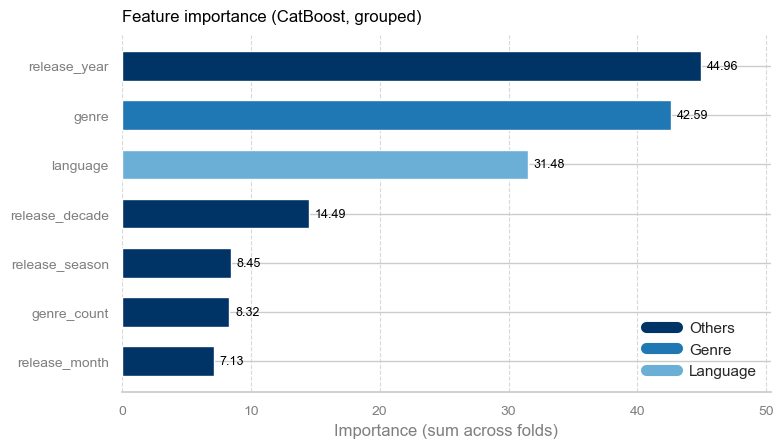

In [131]:
MCK_PALETTE = {
    "dark_blue":  "#003366",  # primary bars / others
    "medium_blue":"#1F77B4",  # genre
    "light_blue": "#6BAED6",  # language
    "grey":       "#7F7F7F",  # ticks/labels
    "light_grey": "#D9D9D9",  # grid
    "black":      "#000000",
}

def set_mckinsey_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="x", color=MCK_PALETTE["light_grey"], linestyle="--", linewidth=0.8)
    ax.tick_params(colors=MCK_PALETTE["grey"], labelsize=10)
    ax.set_facecolor("white")

def plot_importance_mck(imp_df, top_n=20, title="CatBoost Feature Importance (avg across folds)"):
    """
    imp_df: DataFrame dengan kolom ['feature','importance'].
            Sudah boleh berisi 'genre' dan 'language' sebagai grup.
    top_n : jumlah fitur teratas yang ditampilkan (None = semua).
    """
    dfp = imp_df.sort_values("importance", ascending=False).copy()
    if top_n is not None:
        dfp = dfp.head(top_n)
    dfp = dfp.iloc[::-1]

    def _pick_color(feat):
        if feat == "genre":
            return MCK_PALETTE["medium_blue"]
        if feat == "language":
            return MCK_PALETTE["light_blue"]
        return MCK_PALETTE["dark_blue"]

    colors = [_pick_color(f) for f in dfp["feature"]]

    h = 0.6 if len(dfp) <= 20 else 0.5
    fig_h = max(4, 0.45 * len(dfp) + 1.5)
    fig, ax = plt.subplots(figsize=(8, fig_h))

    ax.barh(dfp["feature"], dfp["importance"], color=colors, height=h)

    set_mckinsey_axes(ax)
    ax.set_xlabel("Importance (sum across folds)", color=MCK_PALETTE["grey"])
    ax.set_ylabel("")
    ax.set_title(title, color=MCK_PALETTE["black"], fontsize=12, pad=10, loc="left")

    # label nilai di ujung bar
    xmax = float(dfp["importance"].max()) if len(dfp) else 1.0
    ax.set_xlim(0, xmax * 1.12)
    for y, v in enumerate(dfp["importance"].values):
        ax.text(v + xmax * 0.01, y, f"{v:.2f}", va="center",
                color=MCK_PALETTE["black"], fontsize=9)

    # legend kecil manual
    handles = [
        plt.Line2D([0],[0], color=MCK_PALETTE["dark_blue"], lw=8, label="Others"),
        plt.Line2D([0],[0], color=MCK_PALETTE["medium_blue"], lw=8, label="Genre"),
        plt.Line2D([0],[0], color=MCK_PALETTE["light_blue"], lw=8, label="Language"),
    ]
    ax.legend(handles=handles, frameon=False, loc="lower right")

    plt.tight_layout()
    return fig, ax

fig, ax = plot_importance_mck(imp_grouped, top_n=20,
                              title="Feature importance (CatBoost, grouped)")
plt.savefig("../image/catboost_feature_impotance.png", dpi=150)
plt.show()

## Business Question 4: Genre mana yang menguatkan popularitas, dan mana yang melemahkannya?

##### Hypothesis: Terdapat kombinasi genre tertentu yang dapat menghasilkan popularitas lebih atau buruk.

##### Timeframe difokuskan pada periode 1990–2020an karena data era modern dianggap lebih representatif terhadap tren perfilman saat ini, di mana perilisan besar sudah lebih terstruktur. Periode sebelum 1990 cenderung kurang relevan karena perubahan struktur industri film dan distribusi popularitas.

In [135]:
from itertools import compress
from mlxtend.frequent_patterns import apriori, association_rules

def mean_popularity_for_itemset(itemset):
    cols = list(itemset)
    mask_rows = dsub[cols].all(axis=1)  # film mengandung SEMUA genre di itemset (boleh ada genre lain)
    return dsub.loc[mask_rows, "popularity"].mean()

    freq_items["mean_popularity"] = freq_items["itemsets"].apply(mean_popularity_for_itemset)
    freq_items["label"] = freq_items["itemsets"].apply(
    lambda s: " + ".join(sorted([c.replace("is_","") for c in s]))
)

def plot_apriori_for_era(
    df,
    genre_flags,
    mask,
    era_name,
    topn=10,
    min_support=None,
    colors=("#0033A0", "#5BC2E7", "#A7A8AA", "#000000"),
    show_tables=True,
    # >>> NEW: export controls
    figsize=(10, 6), dpi=150,
    save=False, outdir=".", fname_prefix=None,
):
    mck_blue, mck_lightblue, mck_gray, mck_black = colors

    dsub = df.loc[mask].copy()
    if dsub.empty:
        print(f"[{era_name}] No data.")
        return None, None

    genre_bool = dsub[genre_flags].astype(bool)
    if min_support is None:
        min_support = 0.02

    freq_items = apriori(genre_bool, min_support=min_support, use_colnames=True)

    def _mean_pop_for_itemset(itemset):
        cols = list(itemset)
        mask_rows = dsub[cols].all(axis=1)
        return dsub.loc[mask_rows, "popularity"].mean()

    freq_items["mean_popularity"] = freq_items["itemsets"].apply(_mean_pop_for_itemset)
    freq_items["label"] = freq_items["itemsets"].apply(
        lambda s: " + ".join(sorted([c.replace("is_","") for c in s]))
    )

    # to guarantee identical inner plot area, we fix the axes rectangle:
    AX_POS = [0.12, 0.22, 0.86, 0.70]   # [left, bottom, width, height] in figure fraction

    # ----- TOP -----
    top_df = freq_items.sort_values("mean_popularity", ascending=False).head(topn).reset_index(drop=True)
    x = range(len(top_df))
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150, constrained_layout=True)
    ax.set_position(AX_POS)  # <<< fixed axes box
    ax.bar(x, top_df["mean_popularity"], color=mck_blue)
    ax.set_title(f"Top {topn} Genre Sets by Popularity — {era_name}", fontsize=14, loc="left", color=mck_black, fontweight="bold")
    ax.set_ylabel("Mean Popularity", color=mck_black)
    ax.set_xticks(x)
    ax.set_xticklabels([lbl.replace(" + ", "\n") for lbl in top_df["label"]], rotation=0, ha="center", fontsize=9)  # wrap to normalize height
    ax.axhline(0, color=mck_gray, linestyle="--", linewidth=1)
    ax.grid(axis="y", color=mck_gray, linestyle="--", linewidth=0.7, alpha=0.6)
    ax2 = ax.twinx()
    ax2.plot(x, top_df["support"] * 100, marker="o", linestyle="-", linewidth=1.2, color=mck_lightblue, alpha=0.9)
    ax2.set_ylabel("Support (%)", color=mck_lightblue)
    ax2.tick_params(axis="y", labelcolor=mck_lightblue)

    # DO NOT use tight_layout; use fixed axes + standard bbox to keep same pixel size
    if save:
        base = fname_prefix or f"{era_name.replace(' ','_').replace('–','-')}_TOP"
        fig.savefig(f"{outdir}/{base}.png", dpi=dpi, bbox_inches=None)  # <<< fixed canvas size
    plt.show()

    if show_tables:
        print(f"\n[{era_name}] Frequent itemsets (min_support={min_support}) — top by mean popularity")
        display(top_df[["support", "itemsets", "mean_popularity"]])

    # ----- BOTTOM -----
    bot_df = freq_items.sort_values("mean_popularity", ascending=True).head(topn).reset_index(drop=True)
    x = range(len(bot_df))
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150, constrained_layout=True)
    ax.set_position(AX_POS)  # <<< fixed axes box
    ax.bar(x, bot_df["mean_popularity"], color=mck_lightblue)
    ax.set_title(f"Bottom {topn} Genre sets by Popularity — {era_name}", fontsize=14, loc="left", color=mck_black, fontweight="bold")
    ax.set_ylabel("Mean Popularity", color=mck_black)
    ax.set_xticks(x)
    ax.set_xticklabels([lbl.replace(" + ", "\n") for lbl in bot_df["label"]], rotation=0, ha="center", fontsize=9)
    ax.axhline(0, color=mck_gray, linestyle="--", linewidth=1)
    ax.grid(axis="y", color=mck_gray, linestyle="--", linewidth=0.7, alpha=0.6)
    ax2 = ax.twinx()
    ax2.plot(x, bot_df["support"] * 100, marker="o", linestyle="-", linewidth=1.2, color=mck_blue, alpha=0.9)
    ax2.set_ylabel("Support (%)", color=mck_blue)
    ax2.tick_params(axis="y", labelcolor=mck_blue)

    if save:
        base = fname_prefix or f"{era_name.replace(' ','_').replace('–','-')}_BOTTOM"
        fig.savefig(f"{outdir}/{base}.png", dpi=dpi, bbox_inches=None)  # <<< fixed canvas size
    plt.show()

    if show_tables:
        print(f"\n[{era_name}] Frequent itemsets (min_support={min_support}) — bottom by mean popularity")
        display(bot_df[["support", "itemsets", "mean_popularity"]])

    return top_df, bot_df

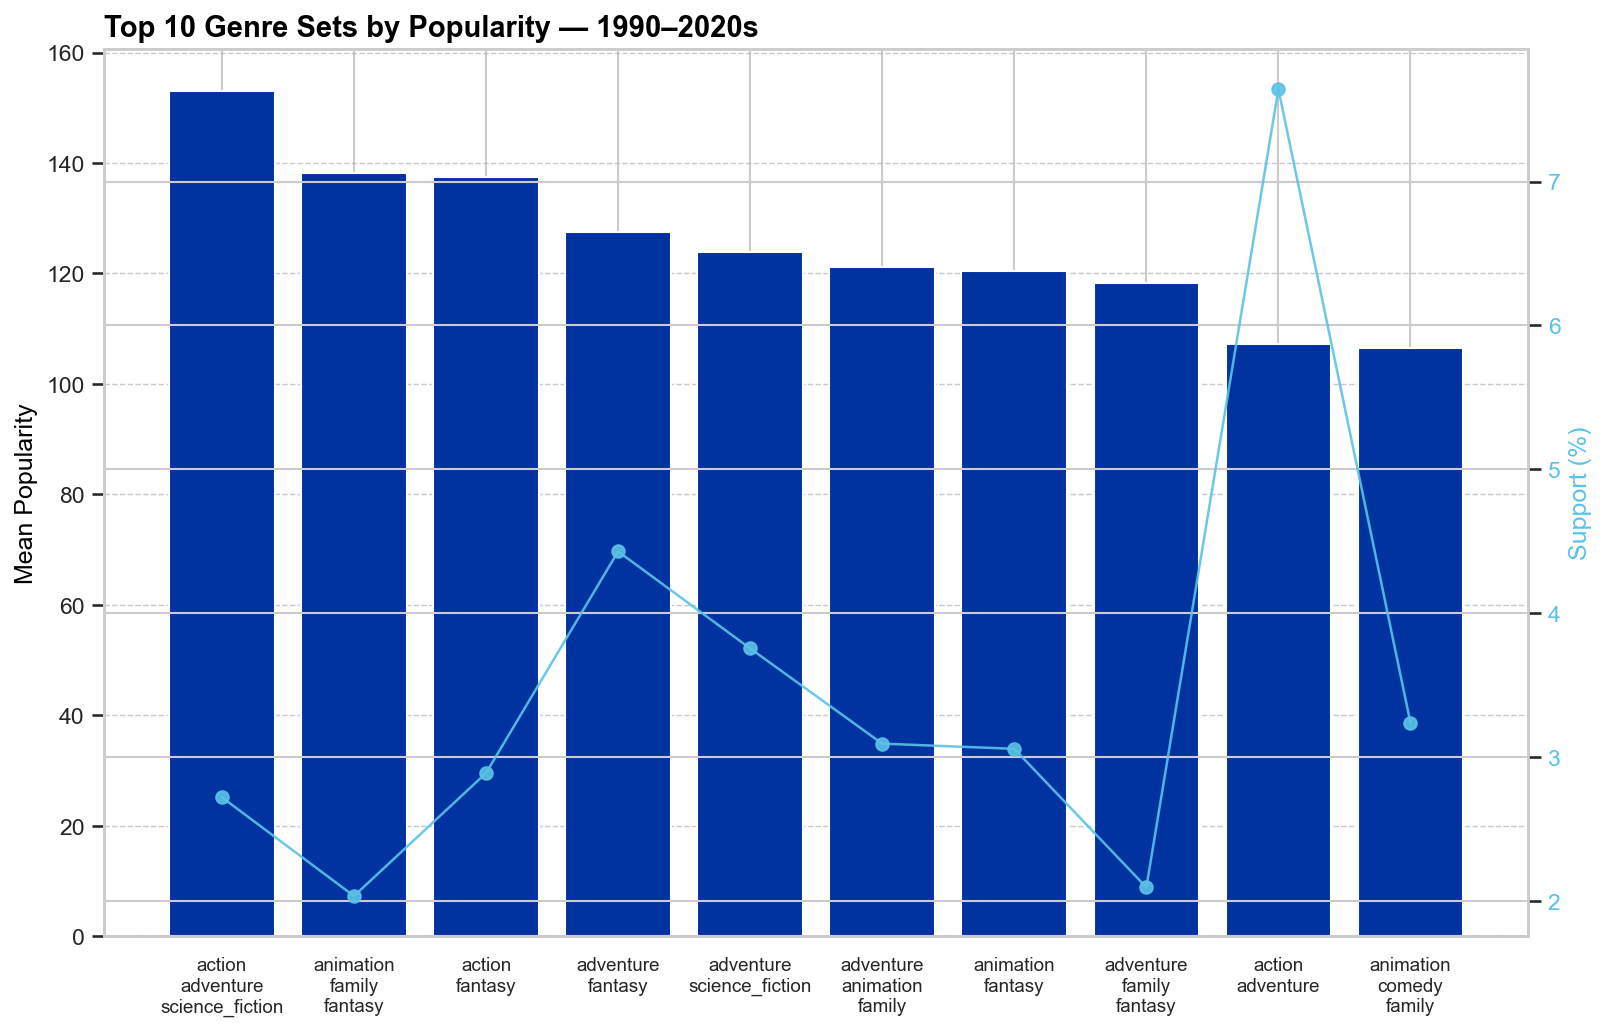


[1990–2020s] Frequent itemsets (min_support=0.02) — top by mean popularity


,support,itemsets,mean_popularity
0,0.027199,"(is_science_fiction, is_action, is_adventure)",153.016881
1,0.020339,"(is_animation, is_fantasy, is_family)",138.158118
2,0.028884,"(is_fantasy, is_action)",137.447008
3,0.044289,"(is_fantasy, is_adventure)",127.527937
4,0.037550,"(is_science_fiction, is_adventure)",123.909304
5,0.030930,"(is_animation, is_family, is_adventure)",121.171097
6,0.030569,"(is_animation, is_fantasy)",120.361024
7,0.020941,"(is_fantasy, is_family, is_adventure)",118.310874
8,0.076423,"(is_action, is_adventure)",107.244450
9,0.032375,"(is_animation, is_comedy, is_family)",106.508636


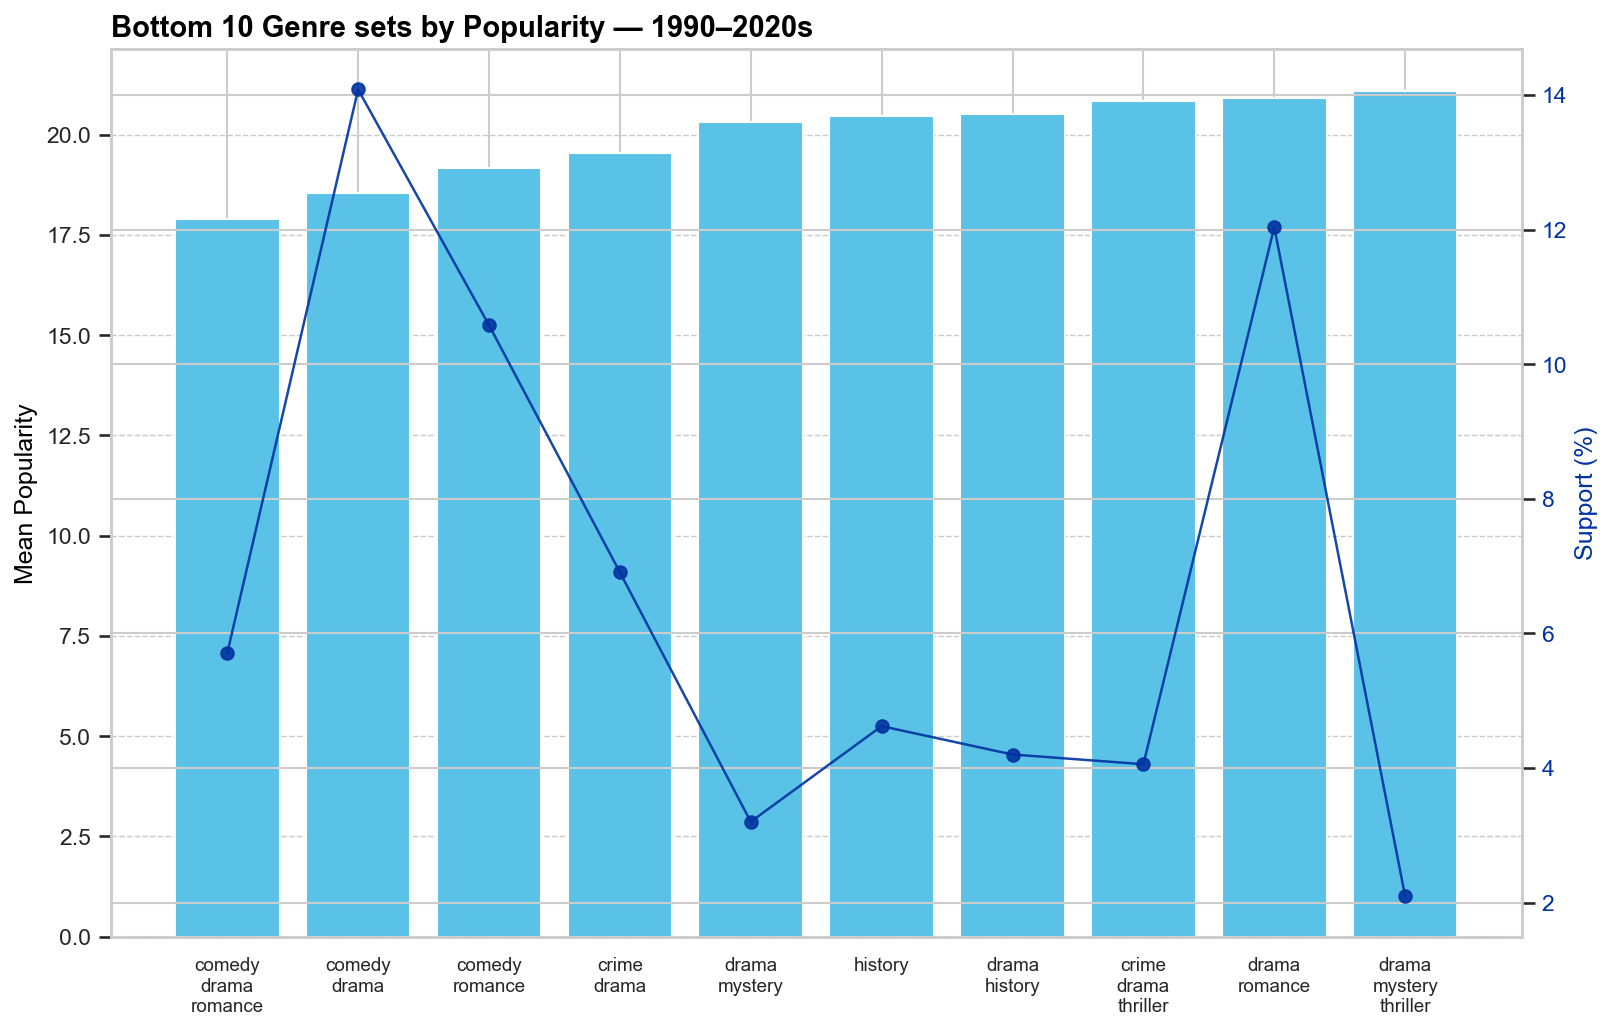


[1990–2020s] Frequent itemsets (min_support=0.02) — bottom by mean popularity


,support,itemsets,mean_popularity
0,0.057047,"(is_romance, is_drama, is_comedy)",17.903922
1,0.140811,"(is_drama, is_comedy)",18.536833
2,0.105789,"(is_romance, is_comedy)",19.160730
3,0.069082,"(is_drama, is_crime)",19.550716
4,0.032013,"(is_drama, is_mystery)",20.315199
5,0.046215,(is_history),20.461562
6,0.042003,"(is_history, is_drama)",20.514977
7,0.040558,"(is_thriller, is_drama, is_crime)",20.829682
8,0.120351,"(is_romance, is_drama)",20.918576
9,0.020941,"(is_thriller, is_drama, is_mystery)",21.079753


In [136]:
genre_flags = [c for c in df.columns if c.startswith("is_")]
mask_90_18 = (data["release_decade"] >= 1990) & (data["release_year"] <= 2022)
plot_apriori_for_era(data, genre_flags, mask_90_18, era_name="1990–2020s", topn=10);

Analisis dilakukan dengan menggunakan algoritma Apriori, yang menghitung kombinasi genre yang sering muncul bersama (frequent itemsets) dengan batas minimum support 2%.
1. Support (%) → proporsi film yang memiliki kombinasi genre tersebut.
2. Mean Popularity → rata-rata popularitas dari film yang memuat kombinasi genre tersebut.
Dengan cara ini, kita dapat mengidentifikasi kombinasi genre yang sinergis meningkatkan popularitas sekaligus menemukan kombinasi yang justru menurunkan popularitas.

##### Insight yang didapatkan melalui algoritma Apriori:
1. Kombinasi genre seperti action–adventure–sci-fi serta animation–family–fantasy konsisten menghasilkan rata-rata popularitas tinggi. Hal ini menunjukkan bahwa blockbuster cenderung terbentuk dari kombinasi genre spektakel yang luas audiensnya (anak-anak, keluarga, hingga dewasa).

2. Kombinasi genre yang berpusat pada drama, romance, dan crime mendominasi posisi bawah dengan popularitas rendah. Meski memiliki support cukup tinggi (cukup banyak film), daya tarik kombinasi ini cenderung terbatas ke segmen tertentu sehingga tidak mencapai popularitas massal.

## Business Question 5: Bagaimana musim/tanggal rilis memengaruhi strategi pemilihan genre?

##### Hypothesis: Terdapat hubungan tertentu pada genre film yang di-release pada bulan tertentu.

In [141]:
season_order = ["winter", "spring", "summer", "fall"]
blockbuster_genres = ["is_action", "is_animation", "is_adventure", "is_science_fiction", "is_fantasy", "is_family"]

req_cols = {"release_decade","release_season","release_month","popularity"}
missing = req_cols - set(data.columns)
assert not missing, f"Missing columns: {missing}"

# flag genre
genre_flags = [c for c in data.columns if c.startswith("is_")]

# era masks
mask_classic  = (data["release_decade"] >= 1970) & (data["release_decade"] <= 2010)
mask_stream   = (data["release_decade"] >= 2010) & (data["release_decade"] <= 2020)
mask_overall  = (data["release_decade"] >= 1970) & (data["release_decade"] <= 2020)

In [142]:
def may_midjuly_vs_baseline_stats(dataframe, start=5.0, end=7.5):
    df_ = dataframe.copy()

    if "release_date" in df_.columns:
        df_["release_date"] = pd.to_datetime(df_["release_date"], errors="coerce")
    else:
        yr = df_["release_year"] if "release_year" in df_.columns else 2000
        mo = df_["release_month"]
        dy = df_["release_day"] if "release_day" in df_.columns else 15
        df_["release_date"] = pd.to_datetime({"year": yr, "month": mo, "day": dy}, errors="coerce")

    # Month fraction in [1, 13)
    month = df_["release_month"].where(df_["release_month"].between(1, 12))
    day   = df_["release_date"].dt.day.fillna(15)
    dim   = df_["release_date"].dt.days_in_month.fillna(30)
    mfrac = (month + (day - 1) / dim).astype(float)

    valid = mfrac.notna() & df_["popularity"].notna()
    mfrac = mfrac[valid]
    pop   = df_.loc[valid, "popularity"].astype(float)

    in_peak = (mfrac >= start) & (mfrac < end)
    peak_mean     = pop[in_peak].mean()
    baseline_mean = pop[~in_peak].mean()
    lift_ratio    = peak_mean / baseline_mean if pd.notna(baseline_mean) else np.nan
    lift_pct      = (lift_ratio - 1.0) * 100 if pd.notna(lift_ratio) else np.nan

    print(
        f"Window [{start}–{end}): "
        f"mean_peak={peak_mean:.2f}, mean_baseline={baseline_mean:.2f}, "
        f"lift={lift_pct:.1f}% (×{lift_ratio:.2f}) | "
        f"n_peak={in_peak.sum()}, n_base={(~in_peak).sum()}"
    )
    return {
        "mean_peak": peak_mean,
        "mean_baseline": baseline_mean,
        "lift_ratio": lift_ratio,
        "lift_pct": lift_pct,
        "n_peak": int(in_peak.sum()),
        "n_baseline": int((~in_peak).sum()),
    }

Window [5.0–7.5): mean_peak=66.08, mean_baseline=29.24, lift=126.0% (×2.26) | n_peak=1743, n_base=7666


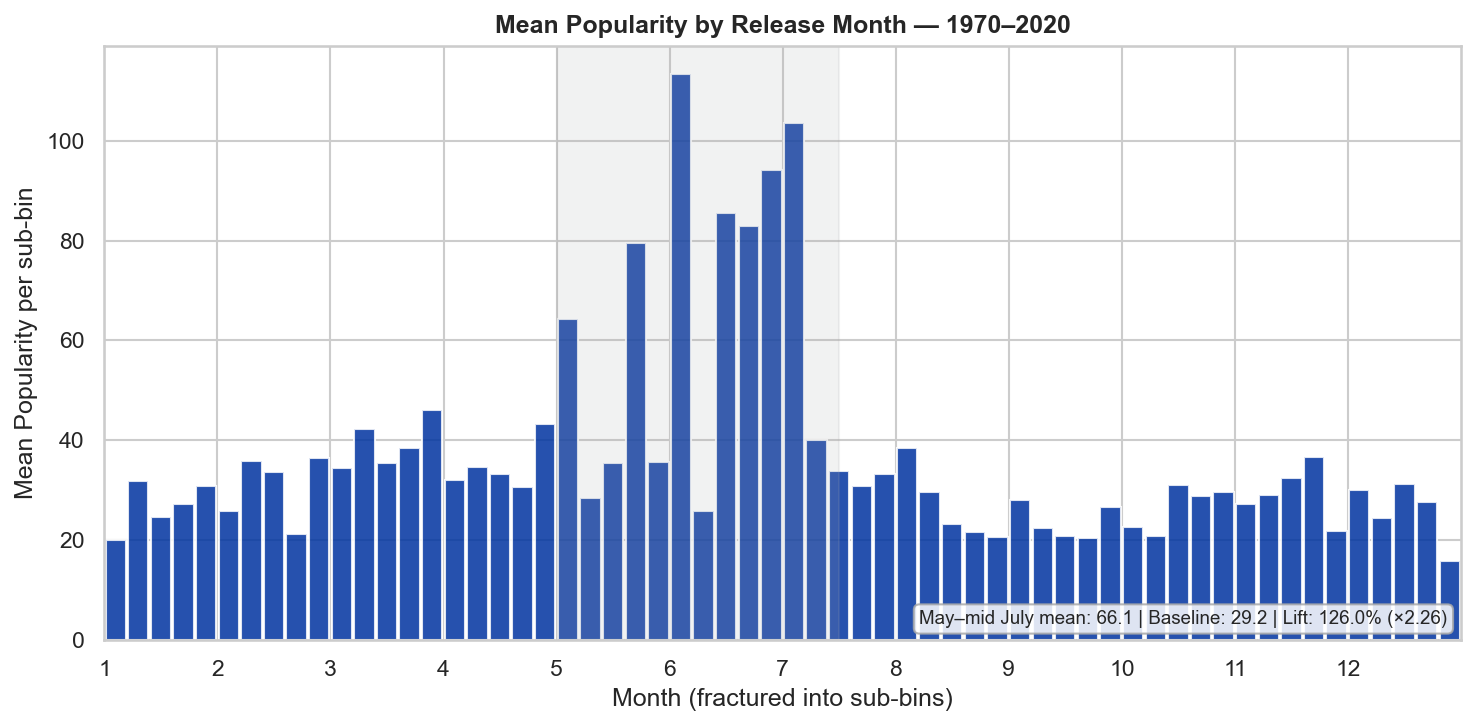

In [143]:
def plot_month_fractured_mean(dataframe, title, color="#0033A0", subbins_per_month=5):
    ds = dataframe.copy()

    if "release_date" in ds.columns:
        ds["release_date"] = pd.to_datetime(ds["release_date"], errors="coerce")
    else:
        # synthesize a pseudo date if needed (fallback uses day=15)
        yr = ds["release_year"] if "release_year" in ds.columns else 2000
        mo = ds["release_month"]
        dy = ds["release_day"] if "release_day" in ds.columns else 15
        ds["release_date"] = pd.to_datetime(
            {"year": yr, "month": mo, "day": dy}, errors="coerce"
        )

    # Month (1..12)
    month = ds["release_month"].where(ds["release_month"].between(1, 12))
    # Day-of-month fraction (fallbacks for NaT)
    day = ds["release_date"].dt.day.fillna(15)
    dim = ds["release_date"].dt.days_in_month.fillna(30)

    # continuous month coordinate in [1,13)
    mfrac = (month + (day - 1) / dim).astype(float)
    valid = mfrac.notna()

    # bin edges: 12 months * subbins
    step = 1.0 / subbins_per_month
    edges = np.arange(1.0, 13.0 + step, step)

    # digitize into sub-bins
    idx = np.digitize(mfrac[valid], edges) - 1
    idx = idx.clip(0, len(edges) - 2)

    # aggregate MEAN popularity per sub-bin
    pop = ds.loc[valid, "popularity"].astype(float).values
    df_bins = pd.DataFrame({"bin": idx, "pop": pop})
    mean_by_bin = df_bins.groupby("bin")["pop"].mean()

    # x positions (center of each sub-bin)
    centers = (edges[:-1] + edges[1:]) / 2

    plt.figure(figsize=(10, 5), dpi=150)
    plt.bar(centers, mean_by_bin.values, width=step*0.9, color=color, alpha=0.85, edgecolor="white")
    # highlight May–Mid July (5–7/5)
    plt.axvspan(5.0, 7.5, color="#A7A8AA", alpha=0.15)

    plt.xlim(1, 13)
    plt.xticks(range(1, 13))
    plt.title(title, fontweight="bold")
    plt.xlabel("Month (fractured into sub-bins)")
    plt.ylabel("Mean Popularity per sub-bin")
    plt.tight_layout()
    
    peak_stats = may_midjuly_vs_baseline_stats(d_overall, 5.0, 7.5)
    caption = (
        f"May–mid July mean: {peak_stats['mean_peak']:.1f} | "
        f"Baseline: {peak_stats['mean_baseline']:.1f} | "
        f"Lift: {peak_stats['lift_pct']:.1f}% (×{peak_stats['lift_ratio']:.2f})"
    )
    plt.gca().text(
        0.99, 0.02, caption,
        transform=plt.gca().transAxes, ha="right", va="bottom",
        fontsize=9, bbox=dict(facecolor="white", edgecolor="#A7A8AA", alpha=0.85, boxstyle="round,pad=0.3")
    )

    plt.show()

d_classic = data.loc[mask_classic]
d_stream  = data.loc[mask_stream]
d_overall = data.loc[mask_overall]

plot_month_fractured_mean(
    d_overall, "Mean Popularity by Release Month — 1970–2020",
    "#0033A0", subbins_per_month=5
)

Grafik histogram menunjukkan distribusi popularitas film sepanjang bulan, dengan fokus pada periode Mei–Agustus. Hasilnya memperlihatkan bahwa lonjakan popularitas secara konsisten terkonsentrasi pada musim panas, terutama pada periode Mei–pertengahan Juli, dengan rata-rata popularitas 2,26× lebih tinggi dibanding bulan lain.

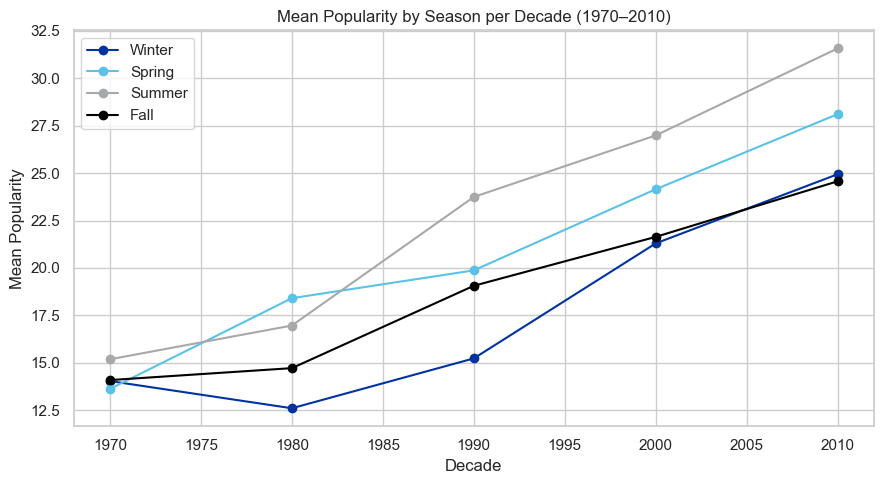

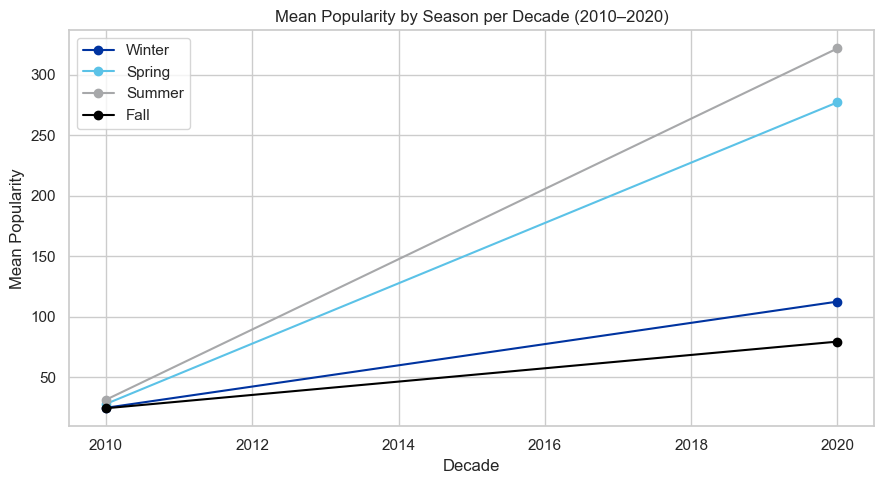

In [145]:
# ===== SEASONAL MEAN POPULARITY PER DECADE =====
# 1970–2010
season_decade_classic = (
    d_classic.groupby(["release_decade","release_season"])["popularity"]
    .mean()
    .unstack()
    .sort_index()
)
plt.figure(figsize=(9,5))
for s, col in zip(season_order, ["#0033A0","#5BC2E7","#A7A8AA","#000000"]):
    if s in season_decade_classic.columns:
        plt.plot(season_decade_classic.index, season_decade_classic[s],
                 marker="o", color=col, label=s.capitalize())
plt.title("Mean Popularity by Season per Decade (1970–2010)")
plt.xlabel("Decade"); plt.ylabel("Mean Popularity"); plt.legend()
plt.tight_layout(); plt.show()

# 2010–2020
season_decade_stream = (
    d_stream.groupby(["release_decade","release_season"])["popularity"]
    .mean()
    .unstack()
    .sort_index()
)
plt.figure(figsize=(9,5))
for s, col in zip(season_order, ["#0033A0","#5BC2E7","#A7A8AA","#000000"]):
    if s in season_decade_stream.columns:
        plt.plot(season_decade_stream.index, season_decade_stream[s],
                 marker="o", color=col, label=s.capitalize())
plt.title("Mean Popularity by Season per Decade (2010–2020)")
plt.xlabel("Decade"); plt.ylabel("Mean Popularity"); plt.legend()
plt.tight_layout(); plt.show()


Grafik tren per dekade menegaskan bahwa musim panas secara konsisten mengalami kenaikan popularitas dari 1970 hingga 2020. Perbandingan dengan musim lain menunjukkan bahwa gap popularitas antara musim panas dan musim lainnya makin melebar di era 2010–2020, mendukung hipotesis bahwa momentum rilis pada musim panas semakin krusial bagi studio besar.


================ 1970–2020 ================
Total movies: 9409
                count       mean   median
release_season                           
winter           2221  28.433766  13.4450
spring           2086  41.046205  14.0915
summer           2271  51.163847  16.2620
fall             2831  26.254207  13.3310


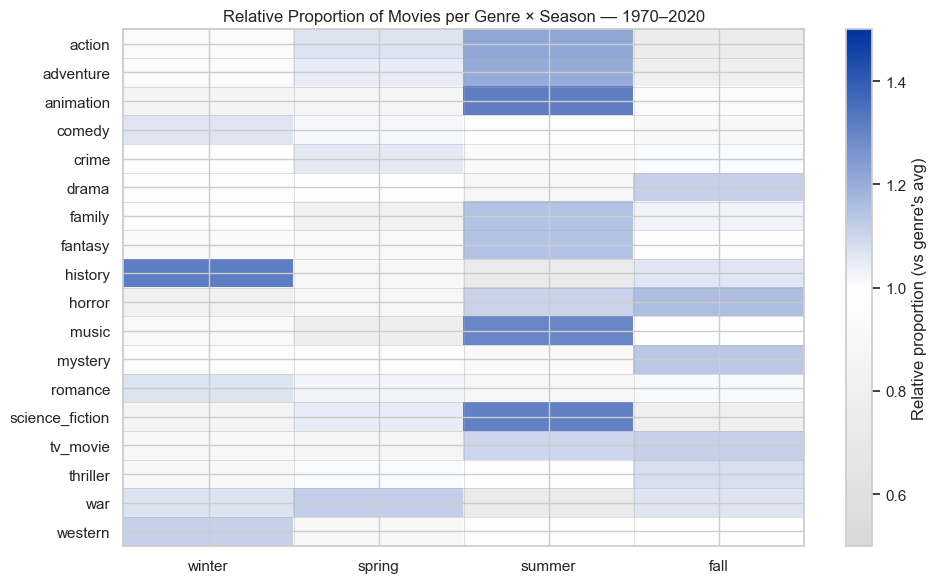

In [147]:
cmap = LinearSegmentedColormap.from_list("mck_div", ["#D9D9D9", "#FFFFFF", "#0033A0"])
norm = TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.5)

eras = {
    "1970–2020": (data["release_decade"] >= 1970) & (data["release_decade"] <= 2020),
}

for era_name, mask in eras.items():
    dsub = data.loc[mask].copy()
    if dsub.empty:
        print(f"[{era_name}] No rows.")
        continue

    season_pop = (
        dsub.groupby("release_season")["popularity"]
            .agg(["count","mean","median"])
            .reindex(season_order)
    )
    print(f"\n================ {era_name} ================")
    print(f"Total movies: {len(dsub)}")
    print(season_pop)

    # Relative proportion per Genre × Season 
    season_genre_era = dsub.groupby("release_season")[genre_flags].mean().T

    cols = [s for s in season_order if s in season_genre_era.columns]
    season_genre_era = season_genre_era[cols]

    rel = season_genre_era.div(season_genre_era.mean(axis=1), axis=0)

    plt.figure(figsize=(10, 6))
    im = plt.imshow(rel, aspect="auto", cmap=cmap, norm=norm)
    cbar = plt.colorbar(im)
    cbar.set_label("Relative proportion (vs genre's avg)")

    plt.yticks(range(len(rel.index)), [g.replace("is_","") for g in rel.index])
    plt.xticks(range(len(rel.columns)), rel.columns)

    # subtle gridlines
    for y in range(len(rel.index)+1):
        plt.axhline(y-0.5, color="#A7A8AA", lw=0.5, alpha=0.5)
    for x in range(len(rel.columns)+1):
        plt.axvline(x-0.5, color="#A7A8AA", lw=0.5, alpha=0.5)

    plt.title(f"Relative Proportion of Movies per Genre × Season — {era_name}")
    plt.tight_layout()
    plt.show()

Analisis heatmap genre × season yang telah dinormalisasi per genre memperlihatkan bahwa genre-genre dengan popularitas tinggi seperti action, sci-fi, animation, fantasy, dan family terkonsentrasi pada musim panas. Konsentrasi ini menjelaskan mengapa musim panas memiliki lonjakan popularitas dibanding musim lainnya — bukan hanya karena waktu rilis itu sendiri, tetapi juga karena film dengan genre “blockbuster” lebih sering diposisikan pada periode ini.

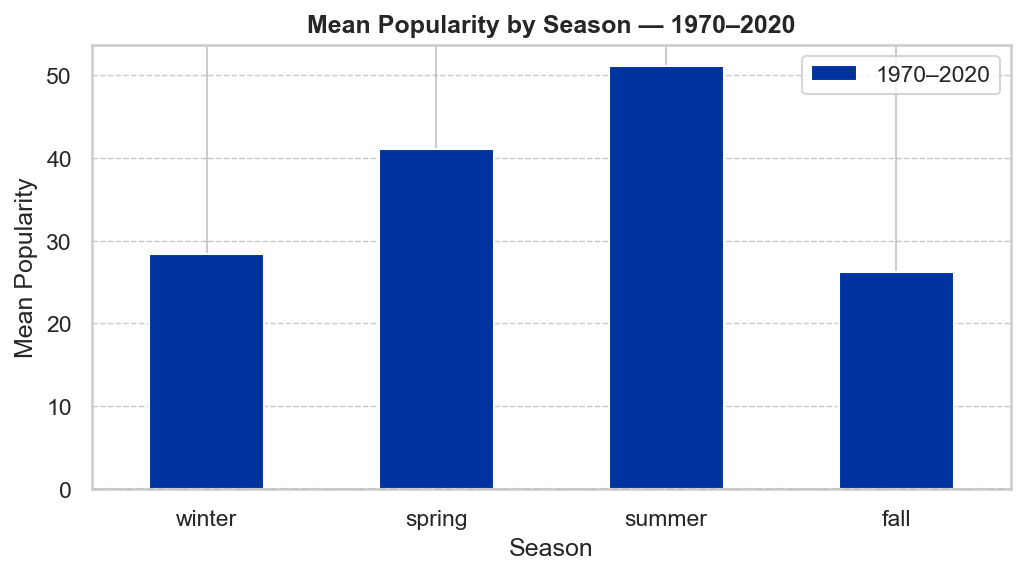

===== 1970–2020 Blockbuster Subset (Context) =====
                count       mean   median
release_season                           
winter            950  39.003258  18.5285
spring            900  65.177790  20.1950
summer           1159  73.419544  21.3320
fall             1115  36.985488  17.1750

**Mann–Whitney U (Summer vs Others)**
n_summer=1159, n_others=2965 | median_summer=21.33, median_others=18.45
U=1,874,576.00, p=0.00001 → SIGNIFICANT (Summer median higher).
**Kruskal–Wallis (All seasons)**
H=34.00, p=0.00000 → SIGNIFICANT (≥1 season differs).


In [149]:
mask_all = (data["release_decade"] >= 1970) & (data["release_decade"] <= 2020)

# Mean popularity by season (1970–2020)
cmp = (
    data.loc[mask_all]
      .groupby("release_season")["popularity"]
      .mean()
      .reindex(season_order)
      .to_frame(name="1970–2020")
)

# Plot
fig, ax = plt.subplots(figsize=(7,4), dpi=150)
cmp.plot(kind="bar", ax=ax, color=["#0033A0"], edgecolor="white")
ax.set_title("Mean Popularity by Season — 1970–2020", fontweight="bold")
ax.set_ylabel("Mean Popularity")
ax.set_xlabel("Season")
ax.tick_params(axis="x", rotation=0)
ax.axhline(0, color="#A7A8AA", linestyle="--", linewidth=1)
ax.grid(axis="y", color="#A7A8AA", linestyle="--", linewidth=0.7, alpha=0.6)
plt.tight_layout()
plt.show()

# Statistical tests on blockbuster subset (single period)
def fmt_num(x): return f"{x:,.2f}"
alpha = 0.05
report_lines = []

dsub = data.loc[mask_all & data[blockbuster_genres].any(axis=1)].copy()
if dsub.empty:
    report_lines.append("**1970–2020** — No blockbuster films found.")
else:
    # Season summary (context)
    season_stats = (
        dsub.groupby("release_season")["popularity"]
            .agg(["count", "mean", "median"])
            .reindex(season_order)
    )
    report_lines.append("===== 1970–2020 Blockbuster Subset (Context) =====")
    report_lines.append(season_stats.to_string())
    report_lines.append("")

    # Samples
    summer = dsub.loc[dsub["release_season"]=="summer", "popularity"].dropna()
    others = dsub.loc[dsub["release_season"]!="summer", "popularity"].dropna()

    # Mann–Whitney U (Summer vs Others)
    if len(summer) > 5 and len(others) > 5:
        u_stat, u_p = mannwhitneyu(summer, others, alternative="two-sided")
        effect_dir = "higher" if summer.median() > others.median() else "lower"
        sig_text = "SIGNIFICANT" if u_p < alpha else "not significant"
        report_lines.append(
            f"**Mann–Whitney U (Summer vs Others)**\n"
            f"n_summer={len(summer)}, n_others={len(others)} | "
            f"median_summer={fmt_num(summer.median())}, median_others={fmt_num(others.median())}\n"
            f"U={fmt_num(u_stat)}, p={u_p:.5f} → {sig_text} (Summer median {effect_dir})."
        )
    else:
        report_lines.append(
            f"**Mann–Whitney U (Summer vs Others)** — Insufficient samples "
            f"(n_summer={len(summer)}, n_others={len(others)})."
        )

    # Kruskal–Wallis across all seasons (no skip logic needed in single-period view)
    season_samples = [dsub.loc[dsub["release_season"]==s, "popularity"].dropna() for s in season_order]
    season_samples = [s for s in season_samples if len(s) > 0]
    if len(season_samples) >= 2:
        k_stat, k_p = kruskal(*season_samples)
        sig_text = "SIGNIFICANT (≥1 season differs)" if k_p < alpha else "not significant"
        report_lines.append(
            f"**Kruskal–Wallis (All seasons)**\n"
            f"H={fmt_num(k_stat)}, p={k_p:.5f} → {sig_text}."
        )
    else:
        report_lines.append("**Kruskal–Wallis** — Insufficient season groups with data.")

print("\n".join(report_lines))


Untuk menguji apakah pola dominasi summer ini bersifat signifikan secara statistik, dilakukan uji Mann–Whitney (summer vs other seasons) dan Kruskal–Wallis (perbandingan seluruh musim). Hasil keduanya menunjukkan signifikansi (p < 0.05), yang berarti keunggulan popularitas summer bukan sekadar pola visual semata, melainkan valid secara statistik. Dengan demikian, dapat dipastikan bahwa musim panas memiliki keunggulan nyata dalam menentukan keberhasilan film dari sisi popularitas.

##### Dari keseluruhan analisis, dapat disimpulkan bahwa strategi rilis pada musim panas terbukti meningkatkan popularitas film, baik dari segi distribusi bulanan, tren dekade, komposisi genre, maupun signifikansi statistik. Hal ini menegaskan mengapa summer blockbuster menjadi strategi utama industri film sejak 1970-an hingga era modern.

## Business Question 6: Apakah bahasa Inggris merupakan kunci untuk popularitas superior?

##### Hypothesis: Tidak selalu. Terdapat kemungkinan di mana bahasa tidak umum menghasilkan tren spesifik yang meningkatkan popularitas suatu film.
Untuk mencari jawaban atas pertanyaan tersebut, digunakan ide untuk mencari bahasa yang memiliki jumlah film lebih sedikit dari bahasa Inggris, namun memiliki median popularitas yang lebih tinggi dari median popularitas film berbahasa Inggris.

#### Scatter Plot Jumlah Film per Bahasa vs Median Popularitas

Implementasi yang memenuhi kebutuhan tersebut adalah dengan membuat sebuah scatter plot yang memetakan jumlah film setiap bahasa dengan median popularitasnya.
1. sumbu X melambangkan jumlah film yang menggunakan suatu bahasa
2. sumbu Y melambangkan median popularitas film dalam bahasa tersebut
3. titik melambangkan letak suatu bahasa dalam peta

In [156]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compute_language_hidden_gems_stats(
    df: pd.DataFrame,
    lang_col: str = "language",
    pop_col: str = "popularity"
) -> pd.DataFrame:
    """
      - film_count : jumlah film per bahasa
      - mean_pop   : rata-rata popularitas
      - median_pop : median popularitas
      - max_pop    : popularitas maksimum (untuk bubble size opsional)
    """
    stats = (
        df.groupby(lang_col)[pop_col]
        .agg(film_count="count", mean_pop="mean", median_pop="median", max_pop="max")
        .reset_index()
    )
    stats[lang_col] = stats[lang_col].astype(str).str.strip().replace({"nan": "unknown", "": "unknown"})
    return stats

Dengan kode visualisasi sebagai berikut,

In [158]:
def plot_hidden_gems(
    stats_df: pd.DataFrame,
    lang_col: str = "language",
    count_col: str = "film_count",
    mean_col: str = "mean_pop",
    size_col: str = "max_pop",
    english_codes=("en",),
    mckinsey_palette: dict | None = None,
    figsize=(11, 7),
    alpha=0.85,
    right_pad_factor: float = 1.18,   # ekstra ruang kanan utk bubble/label (log-scale aware)
):
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    df = stats_df.copy()

    if mckinsey_palette is None:
        mckinsey_palette = {
            "en": "#0033A0",
            "non_en": "#2BB0ED",
            "grid": "#E5E7EB",
            "median": "#6B7280",
            "hidden_zone": "#D1FAE5",
        }

    x_ref = df[count_col].median()
    y_ref = df[mean_col].median()

    en_set = {c.lower() for c in english_codes}
    df["_is_english"] = df[lang_col].astype(str).str.lower().isin(en_set)

    if size_col in df.columns:
        s = df[size_col].astype(float).fillna(0.0)
        bs = 100 + 900 * ((s - s.min())/(s.max()-s.min() + 1e-9))**0.5 if s.max()>0 else np.full(len(df), 200.0)
    else:
        bs = np.full(len(df), 200.0)

    # Plot
    sns.set_theme(style="whitegrid")
    sns.set(rc={"axes.facecolor": "white", "grid.color": mckinsey_palette["grid"]})
    plt.figure(figsize=figsize)
    # beri ruang kanan lebih besar agar tidak crop
    plt.subplots_adjust(left=0.12, right=0.89, top=0.90, bottom=0.13)
    ax = plt.gca()

    colors = np.where(df["_is_english"], mckinsey_palette["en"], mckinsey_palette["non_en"])
    ax.scatter(df[count_col], df[mean_col], s=bs, c=colors, alpha=alpha,
               linewidths=0.8, edgecolors="black")
    ax.set_xscale("log")

    ax.axvline(x_ref, color=mckinsey_palette["median"], linestyle="--", linewidth=1.3, alpha=0.9)
    ax.axhline(y_ref, color=mckinsey_palette["median"], linestyle="--", linewidth=1.3, alpha=0.9)

    xmin, xmax = df[count_col].min(), df[count_col].max()
    ymin, ymax = df[mean_col].min(), df[mean_col].max()
    ax.set_xlim(xmin*0.75, xmax*right_pad_factor)
    ax.set_ylim(ymin - 0.05*(ymax-ymin), ymax + 0.08*(ymax-ymin))
    ax.margins(x=0.08, y=0.06)

    ax.set_title("Film Count vs Popularity (Median) Scatter Plot",
                 fontsize=15, pad=10)
    ax.set_xlabel(f"Film count (Dominance)", fontsize=12)
    ax.set_ylabel("Median Popularity", fontsize=12)

    for _, r in df.iterrows():
        if (r[count_col] < x_ref) and (r[mean_col] > y_ref):      dx,dy,ha,va = (-8,  8,"right","bottom")
        elif (r[count_col] >= x_ref) and (r[mean_col] > y_ref):   dx,dy,ha,va = ( 8,  8,"left" ,"bottom")
        elif (r[count_col] < x_ref) and (r[mean_col] <= y_ref):   dx,dy,ha,va = (-8, -8,"right","top")
        else:                                                     dx,dy,ha,va = ( 8, -8,"left" ,"top")
        ax.annotate(r[lang_col], (r[count_col], r[mean_col]),
                    textcoords="offset points", xytext=(dx, dy),
                    ha=ha, va=va, fontsize=9,
                    weight="bold" if r["_is_english"] else None,
                    bbox=dict(boxstyle="round,pad=0.2",
                              fc=mckinsey_palette["hidden_zone"], ec="none"),
                    clip_on=False)

    legend_elems = [
        Line2D([0],[0], marker='o', color='w', label='English',
               markerfacecolor=mckinsey_palette["en"], markeredgecolor="black", markersize=10),
        Line2D([0],[0], marker='o', color='w', label='Non-English',
               markerfacecolor=mckinsey_palette["non_en"], markeredgecolor="black", markersize=10),
        Line2D([0],[0], color=mckinsey_palette["median"], lw=1.3, ls="--", label='Median reference'),
    ]
    ax.legend(handles=legend_elems, frameon=True, loc="upper right")

    plt.tight_layout()
    # plt.savefig("../image6.png", dpi=150)
    plt.show()

Didapatkan grafik sebagai berikut.

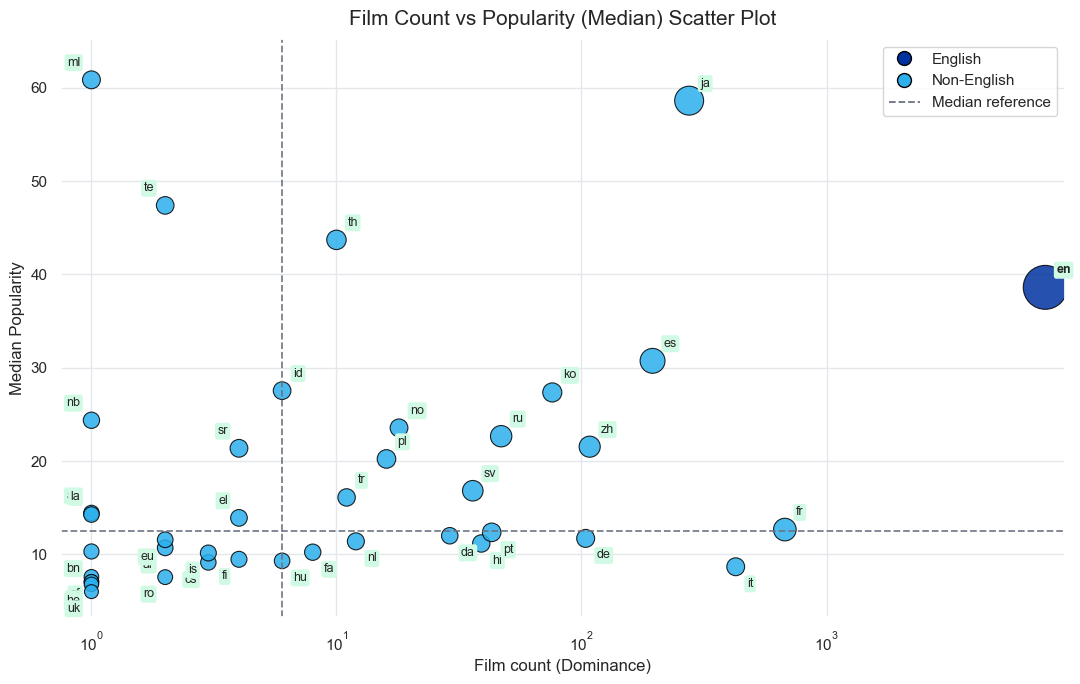

In [167]:
data_lang = data.copy()
lang_stats = compute_language_hidden_gems_stats(data_lang)
plot_hidden_gems(
    stats_df=lang_stats,
    lang_col="language",
    count_col="film_count",
    mean_col="mean_pop",
    size_col="max_pop",
    english_codes=("en",),
    right_pad_factor=1.2
)

Dapat dilihat bahwa terdapat empat bahasa yang memiliki median popularity lebih tinggi dari bahasa Inggris ('ml', 'te', 'th', 'ja'), padahal memiliki Film Count yang jauh lebih sedikit dibanding film berbahasa Inggris. Hal tersebut memberi informasi bahwa bahasa Inggris belum tentu menjadi kunci utama untuk menghasilkan popularitas yang superior.

Meskipun begitu, kita belum punya bukti kuat mengenai hal tersebut. Oleh karena itu, diperlukan suatu pencarian data konkrit terhadap film-film berbahasa non-Inggris yang berhasil meraih popularitas yang tinggi.

#### Pencarian Konkret terhadap Film 'Populer' berbahasa non-Inggris
##### Apa definisi film 'populer'?
Film populer di sini didefinisikan sebagai film yang meraih top 1% global berdasarkan popularitas.
Dengan menetapkan "Top 1% Global" sebagai penanda suatu film populer, didapatkan threshold popularity sebagai berikut.

In [ ]:
TOP_PCT = 0.01
# SMALL_LANGUAGE_SHARE = 2.0 # definisi bahasa kecil: < 2% share

try:
    data
except NameError:
    data = df 

required_cols = {"language", "popularity"}
missing = required_cols - set(map(str.lower, data.columns))
assert {"language", "popularity"} <= set(data.columns), \
    f"Kolom wajib tidak ditemukan. Pastikan ada: {required_cols}"

data_lang = data.copy()

Dengan menggunakan threshold tersebut sebagai batas bawah perhitungan, didapatkan 100 film dengan popularitas di atas threshold.

In [ ]:
def add_top_flag(df, pop_col="popularity", top_pct=0.01, flag_col=None):
    if flag_col is None:
        flag_col = f"is_top{int(top_pct*100)}pct"
    thresh = df[pop_col].quantile(1 - top_pct)
    df[flag_col] = df[pop_col] >= thresh
    return thresh, flag_col

popular_threshold, top_flag_col = add_top_flag(data_lang, pop_col="popularity", top_pct=TOP_PCT)

print(f"Top {int(TOP_PCT*100)}% popularity threshold: {popular_threshold:.4f}")
n_popular = (data["popularity"] >= popular_threshold).sum()
print(f"Jumlah film di atas threshold: {n_popular}")

Dari 100 film tersebut, berikut merupakan list film-film top 1% data global yang menggunakan bahasa selain bahasa Inggris.

In [ ]:
import pandas as pd

def get_non_english_popular_films(
    df: pd.DataFrame,
    title_col: str = "movie_title",
    lang_col: str = "language",
    pop_col: str = "popularity",
    english_codes: tuple[str, ...] = ("en",),
    pct: float = 0.01
):
    thresh = df[pop_col].quantile(1 - pct)
    lang_norm = df[lang_col].astype(str).str.strip().str.lower()
    en_set = {c.lower() for c in english_codes}

    out = (
        df.loc[~lang_norm.isin(en_set) & (df[pop_col] >= thresh),
               [title_col, lang_col, pop_col]]
        .sort_values(pop_col, ascending=False)
        .reset_index(drop=True)
    )

    out.columns = ["movie_title", "language", "popularity"]
    return out

In [ ]:
non_en_hits = get_non_english_popular_films(data_lang)
non_en_hits.head(3)

In [ ]:
print(f"Jumlah film populer berbahasa non-Inggris: {len(non_en_hits)}")

Berdasarkan analisis di atas, ditemukan 12 film yang berasal dari bahasa non-Inggris dan berhasil masuk ke kategori film populer berdasarkan data global (top 1%).
##### Fakta ini membuktikan bahwa bahasa kecil tetap memiliki potensi melahirkan film populer.Bahasa Inggris bukan menjadi kebutuhan esensial untuk menjamin popularitas superior) Masih.aAda ruang bagi bahasa dengan "pangsa kecil" untuk mencatat prestasi tinggi dalam popularitas global.